# HCSumm* / Proposed Dual-Feature Call Graph Summarization

Notebook ini menjalankan pipeline dari **file `.py`** sebagai input:

1. Baca dua file Python: `t0` dan `t1`
2. Ekstrak directed call graph
3. Visualisasi call graph dengan Graphviz
4. Ekstrak execution path
5. Hitung fitur perilaku `f(v)`
6. Bangun directed node2vec random walk dengan outgoing edge
7. Latih Word2Vec untuk mendapatkan embedding `e(v)`
8. Normalisasi `f(v)` dan `e(v)`
9. Fusion menjadi `x(v) = [e'(v) || f'(v)]`
10. Hitung Euclidean distance
11. Ward clustering
12. Bangun summary graph

Catatan: random walk node2vec di notebook ini dibuat sendiri agar **arah edge tetap dipertahankan**.

In [ ]:
# Kalau dijalankan di environment baru, aktifkan cell ini.
# Di Google Colab / Jupyter, hapus tanda komentar jika package belum tersedia.

!pip install networkx numpy scipy scikit-learn pandas graphviz pydot gensim

In [ ]:
!{sys.executable} -m pip install scipy

In [1]:
import ast
import os
import random
import numpy as np
import pandas as pd
import networkx as nx

from IPython.display import display, Image
from graphviz import Digraph

# from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

try:
    from gensim.models import Word2Vec
except Exception as e:
    print("Gensim belum tersedia atau bermasalah. Jalankan: pip install gensim")
    raise e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Library loaded.")

Library loaded.


## 1. Set path file program t0 dan t1

Ganti `FILE_T0` dan `FILE_T1` sesuai lokasi file `.py` yang ingin dibandingkan.

In [2]:
# =========================
# GANTI PATH FILE DI SINI
# =========================

FILE_T0 = '/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/app_2.0.0.py'
FILE_T1 = '/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/app_2.2.0.py'

# Jumlah cluster untuk dry run / synthetic scenario
K_CLUSTERS = 2

# Parameter directed node2vec
EMBED_DIM = 4
WALK_LENGTH = 10
NUM_WALKS = 200
P_RETURN = 1.0
Q_INOUT = 1.0

print("FILE_T0:", FILE_T0)
print("FILE_T1:", FILE_T1)

FILE_T0: /Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/app_2.0.0.py
FILE_T1: /Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/app_2.2.0.py


## 2. Fungsi ekstraksi directed call graph dari file `.py`

Extractor ini membaca AST Python dan membangun `nx.DiGraph`.
Node = fungsi/method, edge = relasi pemanggilan fungsi.

Untuk menjaga graf tetap bersih, edge hanya ditambahkan jika callee merupakan fungsi yang didefinisikan di file yang sama.

In [3]:
class CallGraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.graph = nx.DiGraph()
        self.current_function = None
        self.defined_functions = set()

    def visit_FunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

def _get_callee_name(call_node):
    if isinstance(call_node.func, ast.Name):
        return call_node.func.id
    if isinstance(call_node.func, ast.Attribute):
        return call_node.func.attr
    return None

class CallEdgeExtractor(ast.NodeVisitor):
    def __init__(self, graph, defined_functions):
        self.graph = graph
        self.defined_functions = defined_functions
        self.current_function = None

    def visit_FunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_AsyncFunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_Call(self, node):
        callee = _get_callee_name(node)
        if self.current_function and callee in self.defined_functions:
            self.graph.add_edge(self.current_function, callee)
        self.generic_visit(node)

def extract_call_graph_from_py(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        source = f.read()

    tree = ast.parse(source)

    node_extractor = CallGraphExtractor()
    node_extractor.visit(tree)

    edge_extractor = CallEdgeExtractor(node_extractor.graph, node_extractor.defined_functions)
    edge_extractor.visit(tree)

    return node_extractor.graph, source

print("Call graph extractor ready.")

Call graph extractor ready.


## 3. Fungsi visualisasi call graph dengan Graphviz

In [4]:
def graph_to_graphviz(G, title="Call Graph"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle", style="filled", fillcolor="lightblue", fontname="Arial")

    for n in G.nodes():
        dot.node(str(n), str(n))

    for u, v in G.edges():
        dot.edge(str(u), str(v))

    return dot

def show_graph(G, filename, title="Call Graph"):
    dot = graph_to_graphviz(G, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

print("Graphviz helpers ready.")

Graphviz helpers ready.


## 4. Baca file t0 dan t1, ekstrak call graph, dan visualisasikan

In [5]:
G_t0, source_t0 = extract_call_graph_from_py(FILE_T0)
G_t1, source_t1 = extract_call_graph_from_py(FILE_T1)

print("=== SOURCE t0 ===")
print(source_t0)
print("\n=== SOURCE t1 ===")
print(source_t1)

print("\n=== CALL GRAPH t0 ===")
print("Nodes:", list(G_t0.nodes()))
print("Edges:", list(G_t0.edges()))

print("\n=== CALL GRAPH t1 ===")
print("Nodes:", list(G_t1.nodes()))
print("Edges:", list(G_t1.edges()))

=== SOURCE t0 ===
import functools
import inspect
import logging
import os
import sys
import typing as t
import weakref
from datetime import timedelta
from itertools import chain
from threading import Lock
from types import TracebackType

from werkzeug.datastructures import Headers
from werkzeug.datastructures import ImmutableDict
from werkzeug.exceptions import BadRequest
from werkzeug.exceptions import BadRequestKeyError
from werkzeug.exceptions import HTTPException
from werkzeug.exceptions import InternalServerError
from werkzeug.local import ContextVar
from werkzeug.routing import BuildError
from werkzeug.routing import Map
from werkzeug.routing import MapAdapter
from werkzeug.routing import RequestRedirect
from werkzeug.routing import RoutingException
from werkzeug.routing import Rule
from werkzeug.wrappers import Response as BaseResponse

from . import cli
from . import json
from .config import Config
from .config import ConfigAttribute
from .ctx import _AppCtxGlobals
from .ctx i

Visualisasi Call Graph t0


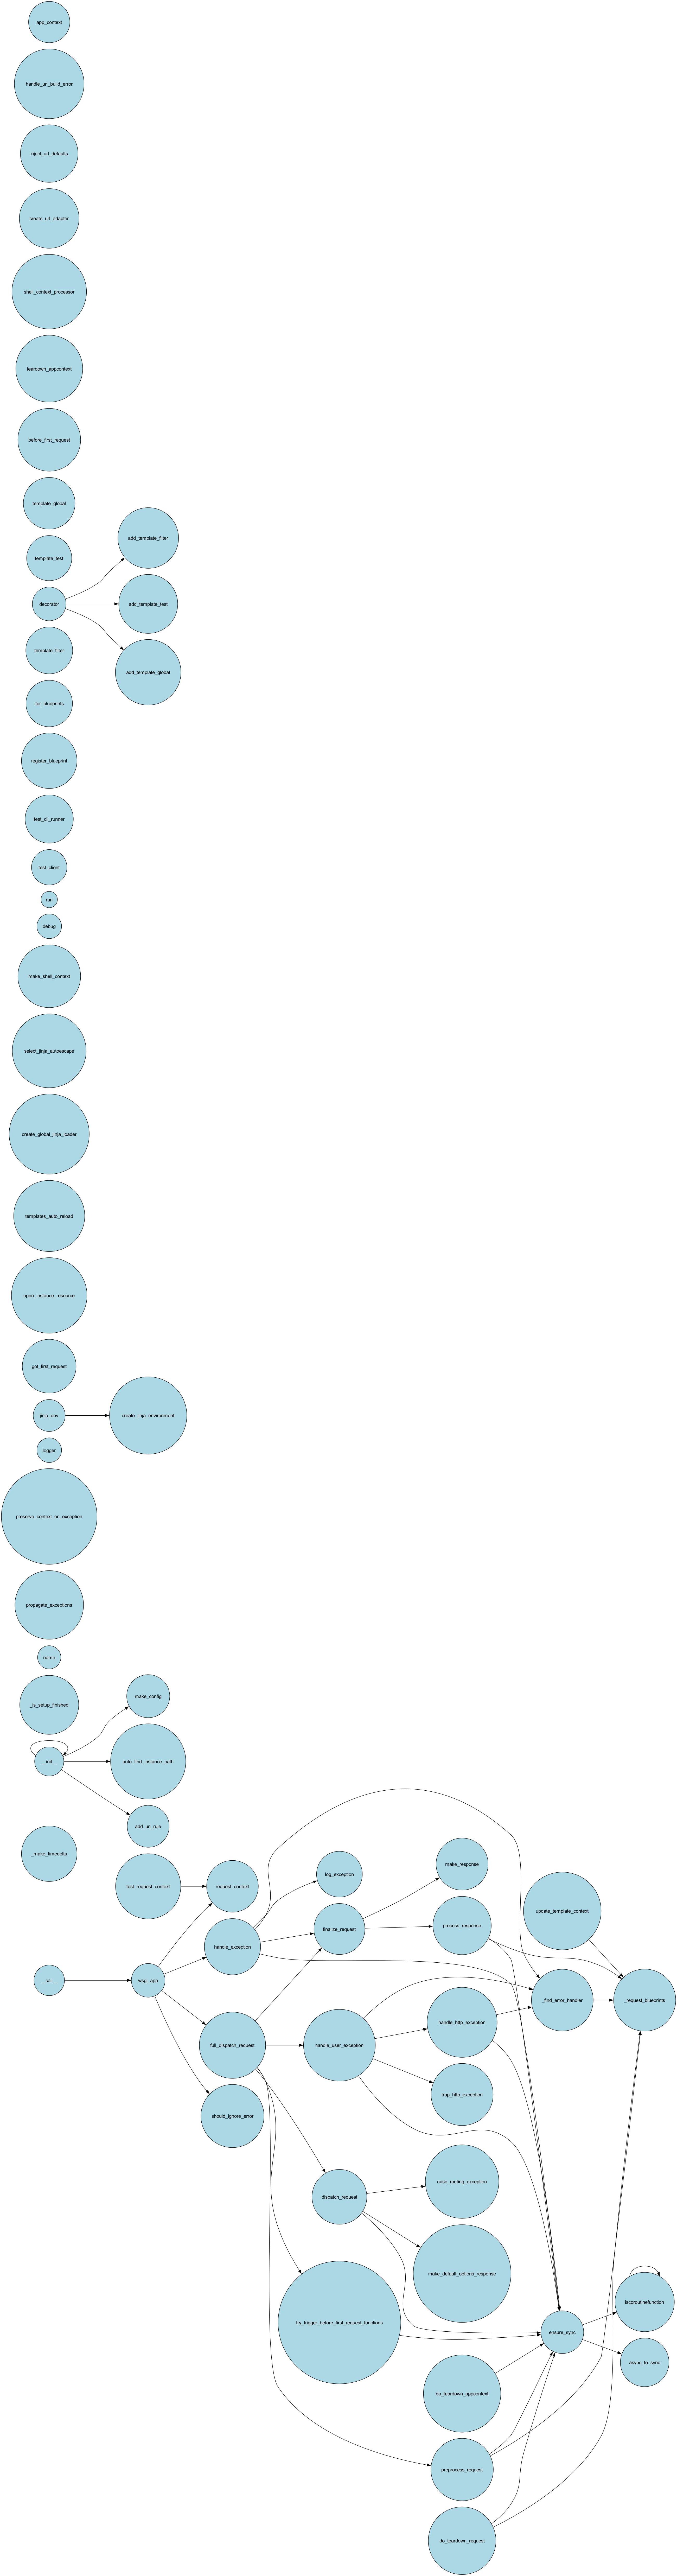

Visualisasi Call Graph t1


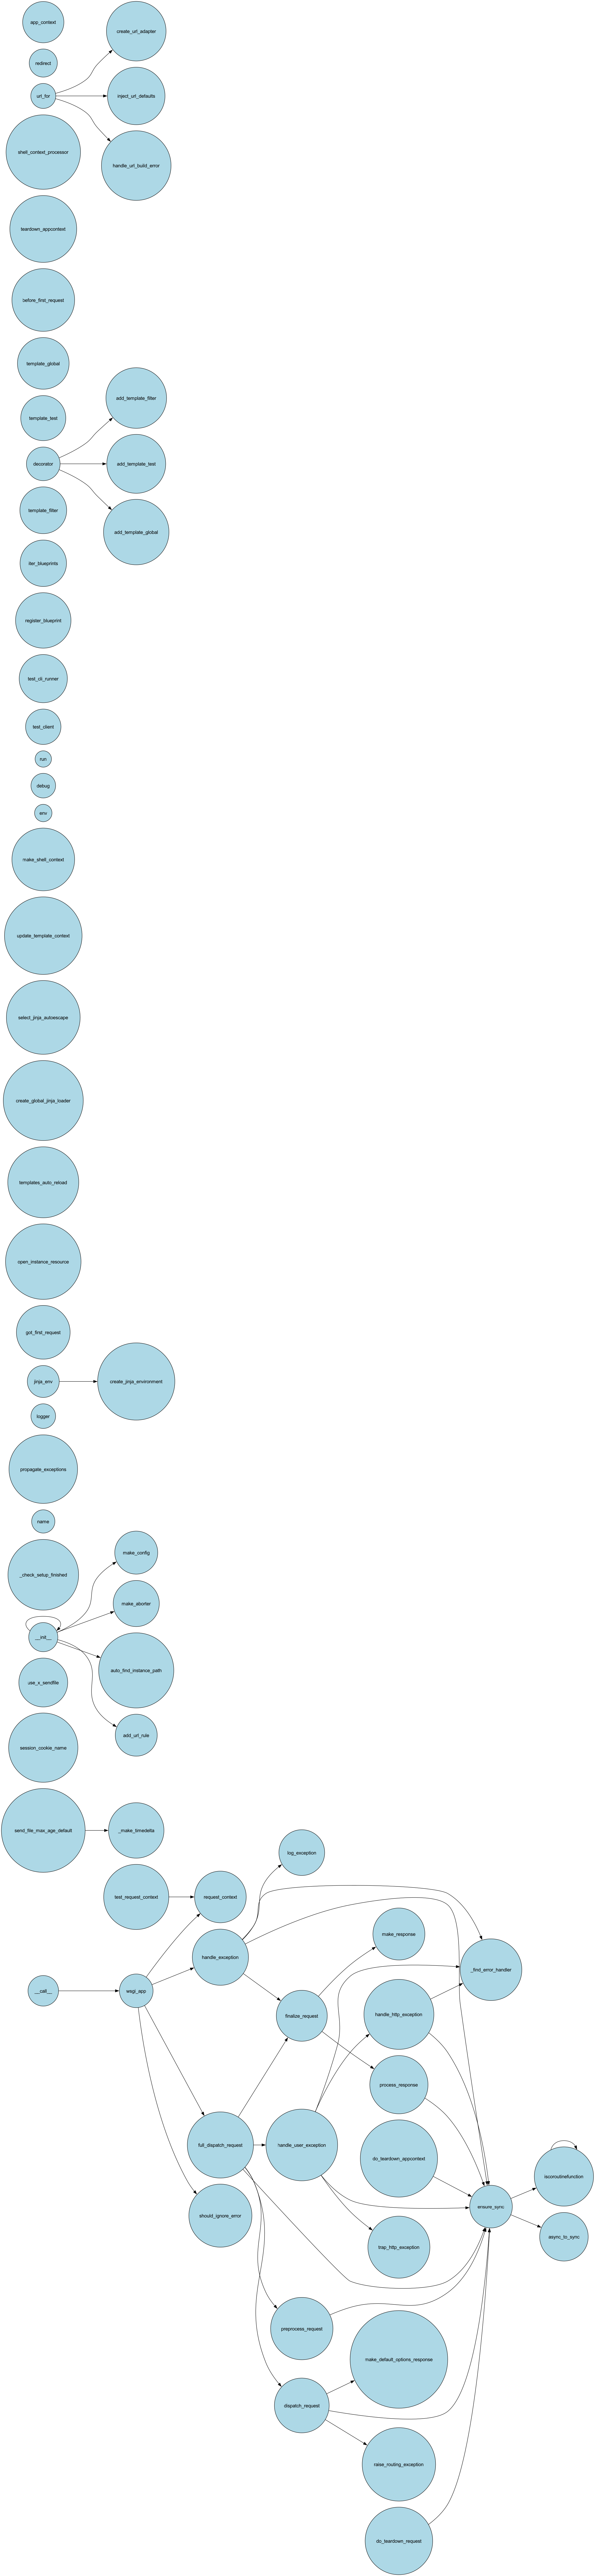

'call_graph_t1.png'

In [6]:
print("Visualisasi Call Graph t0")
show_graph(G_t0, "call_graph_t0", "Call Graph t0")

print("Visualisasi Call Graph t1")
show_graph(G_t1, "call_graph_t1", "Call Graph t1")

# Fungsi-fungsi pipeline HCSumm* / Proposed Method

## 5. Execution path dan fitur perilaku `f(v)`

Definisi yang digunakan:
- Execution path = simple path yang mengikuti arah edge dan berakhir di exit node.
- Exit node = node dengan out-degree 0.
- Node dihitung jika dilewati path, baik sebagai node awal, tengah, maupun akhir.
- `f(v,l)` = jumlah path panjang `l` yang memuat node `v`.

In [7]:
def get_exit_nodes(G):
    return [n for n in G.nodes() if G.out_degree(n) == 0]

def extract_execution_paths(G):
    exit_nodes = get_exit_nodes(G)
    paths = []

    for start in G.nodes():
        for end in exit_nodes:
            if start == end:
                continue
            try:
                for path in nx.all_simple_paths(G, start, end):
                    if len(path) > 1:
                        paths.append(path)
            except nx.NetworkXNoPath:
                pass

    # Remove duplicates while preserving order
    seen = set()
    unique_paths = []
    for p in paths:
        key = tuple(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)

    return unique_paths

def build_path_length_profile(G, paths):
    if not paths:
        return {n: np.array([], dtype=float) for n in G.nodes()}, 0

    L = max(len(p) - 1 for p in paths)
    f = {n: np.zeros(L, dtype=float) for n in G.nodes()}

    for p in paths:
        length = len(p) - 1
        idx = length - 1
        for v in p:
            f[v][idx] += 1

    return f, L

def normalize_f_l1(f):
    f_norm = {}
    for v, vec in f.items():
        s = vec.sum()
        if s > 0:
            f_norm[v] = vec / s
        else:
            f_norm[v] = vec.copy()
    return f_norm

def print_paths(paths):
    for i, p in enumerate(paths, 1):
        print(f"P{i}: {' -> '.join(map(str, p))} | length={len(p)-1}")

def features_to_dataframe(feat_dict, prefix="dim"):
    if not feat_dict:
        return pd.DataFrame()
    nodes = list(feat_dict.keys())
    max_len = max((len(v) for v in feat_dict.values()), default=0)
    data = []
    for n in nodes:
        vec = feat_dict[n]
        row = list(vec) + [np.nan] * (max_len - len(vec))
        data.append(row)
    cols = [f"{prefix}{i+1}" for i in range(max_len)]
    return pd.DataFrame(data, index=nodes, columns=cols)

def compute_node_depth(G):
    # root = semua node dengan indeg = 0
    roots = [n for n, d in G.in_degree() if d == 0]

    # inisialisasi depth
    depth = {v: float('inf') for v in G.nodes()}

    # BFS dari semua root
    from collections import deque

    queue = deque()
    for r in roots:
        depth[r] = 0
        queue.append(r)

    while queue:
        u = queue.popleft()
        for v in G.successors(u):
            if depth[v] > depth[u] + 1:
                depth[v] = depth[u] + 1
                queue.append(v)

    return depth
    
def build_compact_behavior_feature_epl(G, paths):
    import numpy as np

    # 1. Path-length profile
    f_path, L = build_path_length_profile(G, paths)

    # 2. EPL
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total = vec.sum()
        
        if total > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg_value = max(indeg.values()) if indeg else 0
    max_outdeg_value = max(outdeg.values()) if outdeg else 0

    max_indeg = max_indeg_value if max_indeg_value > 0 else 1
    max_outdeg = max_outdeg_value if max_outdeg_value > 0 else 1

    # 4. Depth
    depth = compute_node_depth(G)
    
    finite_depths = [d for d in depth.values() if d < float('inf')]
    max_depth = max(finite_depths) if finite_depths else 1

    depth_norm = {}
    
    for v in G.nodes():
        if depth[v] == float('inf'):
            depth_norm[v] = 1.0
        else:
            depth_norm[v] = depth[v] / max_depth if max_depth > 0 else 0.0

    # 5. PageRank
    pagerank = nx.pagerank(G, alpha=0.85)

    max_pr_value = max(pagerank.values()) if pagerank else 0
    max_pr = max_pr_value if max_pr_value > 0 else 1
    
    pagerank_norm = {
        v: pagerank[v] / max_pr
        for v in G.nodes()
    }
    
    # 6. Final f*(v)
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm,
            depth_norm[v],
            pagerank_norm[v]
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, depth, depth_norm, pagerank, pagerank_norm, L

FEATURE_INDEX = {
    "EPL": 0,
    "indeg": 1,
    "outdeg": 2,
    "depth": 3,
    "pagerank": 4,
}

def select_behavior_features(f_star, selected_features):
    """
    Select subset of behavioral-role features from existing f_star.

    f_star[v] order:
        0 = EPL
        1 = indeg
        2 = outdeg
        3 = depth
        4 = pagerank
    """
    idx = [FEATURE_INDEX[name] for name in selected_features]

    selected = {
        v: np.array(f_star[v])[idx]
        for v in f_star
    }

    return selected


print("Execution path and f(v) functions ready.")

Execution path and f(v) functions ready.


## 6. Directed node2vec random walk

Bagian ini memastikan random walk hanya mengikuti **outgoing neighbors**.
Dengan demikian, sequence walk tetap mempertahankan arah pada call graph.

In [8]:
def directed_node2vec_walk(G, start_node, walk_length, p=1.0, q=1.0):
    walk = [start_node]

    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = list(G.successors(curr))  # penting: outgoing neighbors saja

        if len(neighbors) == 0:
            break  # exit node

        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            weights = []

            for nbr in neighbors:
                if nbr == prev:
                    weight = 1.0 / p
                elif G.has_edge(prev, nbr) or G.has_edge(nbr, prev):
                    weight = 1.0
                else:
                    weight = 1.0 / q
                weights.append(weight)

            probs = np.array(weights, dtype=float)
            probs = probs / probs.sum()
            next_node = np.random.choice(neighbors, p=probs)

        walk.append(next_node)

    return walk

def generate_directed_node2vec_walks(G, num_walks=80, walk_length=10, p=1.0, q=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        random.shuffle(nodes)
        for n in nodes:
            walk = directed_node2vec_walk(G, n, walk_length, p=p, q=q)
            walks.append([str(x) for x in walk])

    return walks

def compute_directed_node2vec_embedding(
    G,
    dimensions=4,
    walk_length=10,
    num_walks=200,
    p=1.0,
    q=1.0,
    seed=42,
    window=5,
    epochs=100
):
    walks = generate_directed_node2vec_walks(
        G,
        num_walks=num_walks,
        walk_length=walk_length,
        p=p,
        q=q,
        seed=seed
    )

    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=window,
        min_count=1,
        sg=1,          # skip-gram
        workers=1,
        seed=seed,
        epochs=epochs
    )

    e = {}
    for n in G.nodes():
        key = str(n)
        if key in model.wv:
            e[n] = model.wv[key]
        else:
            # fallback jika node tidak muncul dalam walk
            e[n] = np.zeros(dimensions)

    return e, walks, model

def normalize_e_l2(e):
    e_norm = {}
    for v, vec in e.items():
        norm = np.linalg.norm(vec)
        if norm > 0:
            e_norm[v] = vec / norm
        else:
            e_norm[v] = vec.copy()
    return e_norm

print("Directed node2vec functions ready.")

Directed node2vec functions ready.


## 7. Fusion, distance, Ward clustering, dan summary graph

In [9]:
def align_feature_dimensions(feat_dict, target_len):
    aligned = {}
    for n, vec in feat_dict.items():
        vec = np.asarray(vec, dtype=float)
        if len(vec) < target_len:
            vec = np.concatenate([vec, np.zeros(target_len - len(vec))])
        aligned[n] = vec
    return aligned

def fuse_features(e_norm, f_norm, alpha=1.0, beta=1.0):
    import numpy as np

    nodes_e = set(e_norm.keys())
    nodes_f = set(f_norm.keys())

    if nodes_e != nodes_f:
        missing_in_e = nodes_f - nodes_e
        missing_in_f = nodes_e - nodes_f

        raise ValueError(
            "Node mismatch between embedding features and behavior features. "
            f"Missing in e_norm: {missing_in_e}. "
            f"Missing in f_norm: {missing_in_f}."
        )

    nodes = list(e_norm.keys())
    x = {}

    for n in nodes:
        e_vec = np.asarray(e_norm[n], dtype=float)
        f_vec = np.asarray(f_norm[n], dtype=float)

        x[n] = np.concatenate([
            alpha * e_vec,
            beta * f_vec
        ])

    return x

def compute_distance_matrix(x):
    nodes = sorted(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) <= 1:
        return nodes, np.zeros((len(nodes), len(nodes)))

    if not np.isfinite(X).all():
        raise ValueError("Feature matrix contains NaN or inf.")

    dist = squareform(pdist(X, metric="euclidean"))
    return nodes, dist

def ward_clustering(x, k=2):
    nodes = sorted(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) == 0:
        return {}, None
    
    if not np.isfinite(X).all():
        raise ValueError("Feature matrix contains NaN or inf.")

    if len(nodes) == 1:
        return {1: [nodes[0]]}, None

    k = min(k, len(nodes))
    Z = linkage(X, method="ward")
    labels = fcluster(Z, k, criterion="maxclust")

    clusters = {}
    for i, n in enumerate(nodes):
        clusters.setdefault(int(labels[i]), []).append(n)

    return clusters, Z

def build_summary_graph(G, clusters):
    node_to_cluster = {}
    for cid, members in clusters.items():
        for n in members:
            node_to_cluster[n] = cid

    S = nx.DiGraph()
    for cid in clusters:
        S.add_node(f"C{cid}")

    for u, v in G.edges():
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is not None and cv is not None and cu != cv:
            S.add_edge(f"C{cu}", f"C{cv}")

    return S, node_to_cluster

def print_clusters(clusters):
    for cid, members in sorted(clusters.items()):
        print(f"C{cid}: {members}")

print("Fusion, distance, clustering, and summary graph functions ready.")

Fusion, distance, clustering, and summary graph functions ready.


Feature Experiment Settings

In [122]:
# ============================================================
# Feature ablation experiment settings
# ============================================================

FEATURE_EXPERIMENTS = {
    "baseline_current": ("EPL", "indeg", "outdeg", "depth"),
    "full_with_pagerank": ("EPL", "indeg", "outdeg", "depth", "pagerank"),
    "without_EPL": ("indeg", "outdeg", "depth", "pagerank"),
    "without_indeg": ("EPL", "outdeg", "depth", "pagerank"),
    "without_outdeg": ("EPL", "indeg", "depth", "pagerank"),
    "without_depth": ("EPL", "indeg", "outdeg", "pagerank"),
    "pagerank_only": ("pagerank",),
    "EPL_only": ("EPL",),
}

ACTIVE_FEATURE_SET = "full_with_pagerank"
ACTIVE_REPRESENTATION_MODE = "behavior_only" #fused or behavior_only

selected_features = FEATURE_EXPERIMENTS[ACTIVE_FEATURE_SET]

print("Active feature set:", ACTIVE_FEATURE_SET)
print("Selected behavior features:", selected_features)
print("Selected representation mode:", ACTIVE_REPRESENTATION_MODE)

Active feature set: full_with_pagerank
Selected behavior features: ('EPL', 'indeg', 'outdeg', 'depth', 'pagerank')
Selected representation mode: behavior_only


# Proses t0 satu per satu

## 8. t0 — Execution path

In [123]:
paths_t0 = extract_execution_paths(G_t0)
exit_t0 = get_exit_nodes(G_t0)

print("Exit nodes t0:", exit_t0)
print("\nExecution paths t0:")
print_paths(paths_t0)

Exit nodes t0: ['_make_timedelta', '_is_setup_finished', 'name', 'propagate_exceptions', 'preserve_context_on_exception', 'logger', 'got_first_request', 'make_config', 'auto_find_instance_path', 'open_instance_resource', 'templates_auto_reload', 'create_jinja_environment', 'create_global_jinja_loader', 'select_jinja_autoescape', 'make_shell_context', 'debug', 'run', 'test_client', 'test_cli_runner', 'register_blueprint', 'iter_blueprints', 'add_url_rule', 'template_filter', 'add_template_filter', 'template_test', 'add_template_test', 'template_global', 'add_template_global', 'before_first_request', 'teardown_appcontext', 'shell_context_processor', 'trap_http_exception', 'log_exception', 'raise_routing_exception', 'make_default_options_response', 'should_ignore_error', 'async_to_sync', 'make_response', 'create_url_adapter', 'inject_url_defaults', 'handle_url_build_error', 'app_context', 'request_context', '_request_blueprints']

Execution paths t0:
P1: __init__ -> make_config | length=1

## 9. t0 — Hitung `f(v)` dan normalisasi `f'(v)`

In [124]:
f_star_t0, f_t0, epl_t0, epl_norm_t0, indeg_t0, outdeg_t0, depth_t0, depth_norm_t0, pagerank_t0, pagerank_norm_t0, L_t0 = build_compact_behavior_feature_epl(
    G_t0,paths_t0)

print("L_t0 =", L_t0)

print("\nRaw f_path(v) t0:")
display(features_to_dataframe(f_t0, prefix="f"))

print("\nEPL(v) t0:")
display(pd.DataFrame.from_dict(epl_t0, orient="index", columns=["EPL"]))

print("\nEPL'(v) t0:")
display(pd.DataFrame.from_dict(epl_norm_t0, orient="index", columns=["EPL'"]))

print("\nIn-degree t0:")
display(pd.DataFrame.from_dict(indeg_t0, orient="index", columns=["indeg"]))

print("\nOut-degree t0:")
display(pd.DataFrame.from_dict(outdeg_t0, orient="index", columns=["outdeg"]))

print("\nDepth t0:")
display(pd.DataFrame.from_dict(depth_t0, orient="index", columns=["depth"]))

print("\nNormalized depth t0:")
display(pd.DataFrame.from_dict(depth_norm_t0, orient="index", columns=["depth'"]))

print("\nPageRank t0:")
display(pd.DataFrame.from_dict(pagerank_t0, orient="index", columns=["PageRank"]))

print("\nNormalized PageRank t0:")
display(pd.DataFrame.from_dict(pagerank_norm_t0, orient="index", columns=["PageRank'"]))

print("\nUpdated r+(v) t0 = [EPL', indeg', outdeg', depth', PageRank']:")
display(features_to_dataframe(f_star_t0, prefix="r"))

L_t0 = 6

Raw f_path(v) t0:


,f1,f2,f3,f4,f5,f6
iscoroutinefunction,0.0,0.0,0.0,0.0,0.0,0.0
_make_timedelta,0.0,0.0,0.0,0.0,0.0,0.0
__init__,3.0,0.0,0.0,0.0,0.0,0.0
_is_setup_finished,0.0,0.0,0.0,0.0,0.0,0.0
name,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
request_context,2.0,1.0,0.0,0.0,0.0,0.0
test_request_context,1.0,0.0,0.0,0.0,0.0,0.0
wsgi_app,2.0,3.0,9.0,15.0,11.0,4.0
__call__,0.0,2.0,1.0,8.0,7.0,4.0



EPL(v) t0:


,EPL
iscoroutinefunction,0.000000
_make_timedelta,0.000000
__init__,1.000000
_is_setup_finished,0.000000
name,0.000000
...,...
request_context,1.333333
test_request_context,1.000000
wsgi_app,3.954545
__call__,4.454545



EPL'(v) t0:


...

,PageRank
iscoroutinefunction,0.213173
_make_timedelta,0.009014
__init__,0.011447
_is_setup_finished,0.009014
name,0.009014
...,...
request_context,0.020220
test_request_context,0.009014
wsgi_app,0.016676
__call__,0.009014



Normalized PageRank t0:


,PageRank'
iscoroutinefunction,1.000000
_make_timedelta,0.042286
__init__,0.053697
_is_setup_finished,0.042286
name,0.042286
...,...
request_context,0.094854
test_request_context,0.042286
wsgi_app,0.078230
__call__,0.042286



Updated r+(v) t0 = [EPL', indeg', outdeg', depth', PageRank']:


,r1,r2,r3,r4,r5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.000000,0.000000,0.0,0.00,0.042286
__init__,0.166667,0.111111,0.8,1.00,0.053697
_is_setup_finished,0.000000,0.000000,0.0,0.00,0.042286
name,0.000000,0.000000,0.0,0.00,0.042286
...,...,...,...,...,...
request_context,0.222222,0.222222,0.0,0.25,0.094854
test_request_context,0.166667,0.000000,0.2,0.00,0.042286
wsgi_app,0.659091,0.111111,0.8,0.25,0.078230
__call__,0.742424,0.000000,0.2,0.00,0.042286


select active feature t0

In [125]:
# Select active behavioral-role features for t0
f_star_selected_t0 = select_behavior_features(
    f_star_t0,
    selected_features
)

print(f"\nSelected r(v) t0 for feature set: {ACTIVE_FEATURE_SET}")
display(features_to_dataframe(f_star_selected_t0, prefix="r_sel"))


Selected r(v) t0 for feature set: full_with_pagerank


,r_sel1,r_sel2,r_sel3,r_sel4,r_sel5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.000000,0.000000,0.0,0.00,0.042286
__init__,0.166667,0.111111,0.8,1.00,0.053697
_is_setup_finished,0.000000,0.000000,0.0,0.00,0.042286
name,0.000000,0.000000,0.0,0.00,0.042286
...,...,...,...,...,...
request_context,0.222222,0.222222,0.0,0.25,0.094854
test_request_context,0.166667,0.000000,0.2,0.00,0.042286
wsgi_app,0.659091,0.111111,0.8,0.25,0.078230
__call__,0.742424,0.000000,0.2,0.00,0.042286


## 10. t0 — Directed node2vec random walk dan embedding `e(v)`

In [126]:
e_t0, walks_t0, model_t0 = compute_directed_node2vec_embedding(
    G_t0,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t0:")
for w in walks_t0[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t0:")
display(features_to_dataframe(e_t0, prefix="e"))

Contoh 10 random walks t0:
full_dispatch_request -> preprocess_request -> _request_blueprints
preprocess_request -> _request_blueprints
logger
register_blueprint
try_trigger_before_first_request_functions -> ensure_sync -> async_to_sync
handle_user_exception -> _find_error_handler -> _request_blueprints
run
request_context
handle_url_build_error
got_first_request

Raw e(v) t0:


,e1,e2,e3,e4
iscoroutinefunction,-3.564734,3.774781,0.184774,0.392817
_make_timedelta,-0.186860,0.028516,0.002508,0.141949
__init__,-0.706130,-0.302229,3.398208,4.996131
_is_setup_finished,-0.030193,0.084201,0.077214,-0.014452
name,-0.066868,0.204290,-0.002467,0.099854
...,...,...,...,...
request_context,-1.002894,-0.299662,6.046178,1.154565
test_request_context,-2.336025,-1.697924,4.106965,2.269330
wsgi_app,-1.166985,-0.112104,1.585036,-0.494995
__call__,-1.235742,-0.102408,1.621793,-0.497258


## 11. t0 — Normalisasi `e(v)` menjadi `e'(v)`

In [127]:
e_norm_t0 = normalize_e_l2(e_t0)

print("Normalized e'(v) t0:")
display(features_to_dataframe(e_norm_t0, prefix="e'"))

Normalized e'(v) t0:


,e'1,e'2,e'3,e'4
iscoroutinefunction,-0.684202,0.724518,0.035465,0.075396
_make_timedelta,-0.790434,0.120626,0.010608,0.600458
__init__,-0.115932,-0.049620,0.557915,0.820261
_is_setup_finished,-0.253622,0.707290,0.648599,-0.121396
name,-0.282110,0.861879,-0.010409,0.421272
...,...,...,...,...
request_context,-0.160623,-0.047994,0.968351,0.184914
test_request_context,-0.423983,-0.308169,0.745404,0.411878
wsgi_app,-0.574112,-0.055151,0.779777,-0.243518
__call__,-0.588114,-0.048738,0.771843,-0.236655


## 12. t0 — Fusion menjadi `x(v)`

In [128]:
# Pastikan dimensi f(v) konsisten dengan L lokal t0

#x_t0 = fuse_features(e_norm_t0, f_star_t0, alpha=1.0, beta=1.0)
if ACTIVE_REPRESENTATION_MODE == "fused":
    x_t0 = fuse_features(e_norm_t0, f_star_selected_t0, alpha=1.0, beta=1.0)
elif ACTIVE_REPRESENTATION_MODE == "behavior_only":
    x_t0 = f_star_selected_t0
else:
    raise ValueError(f"Unknown representation mode: {ACTIVE_REPRESENTATION_MODE}")

print("Representation mode t0:", ACTIVE_REPRESENTATION_MODE)
print("Final x(v) t0:")
display(features_to_dataframe(x_t0, prefix="x"))

Representation mode t0: behavior_only
Final x(v) t0:


,x1,x2,x3,x4,x5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.000000,0.000000,0.0,0.00,0.042286
__init__,0.166667,0.111111,0.8,1.00,0.053697
_is_setup_finished,0.000000,0.000000,0.0,0.00,0.042286
name,0.000000,0.000000,0.0,0.00,0.042286
...,...,...,...,...,...
request_context,0.222222,0.222222,0.0,0.25,0.094854
test_request_context,0.166667,0.000000,0.2,0.00,0.042286
wsgi_app,0.659091,0.111111,0.8,0.25,0.078230
__call__,0.742424,0.000000,0.2,0.00,0.042286


## 13. t0 — Euclidean distance berdasarkan `x(v)`

In [129]:
nodes_t0, dist_t0 = compute_distance_matrix(x_t0)

dist_df_t0 = pd.DataFrame(dist_t0, index=nodes_t0, columns=nodes_t0)
print("Distance matrix t0:")
display(dist_df_t0.round(4))

Distance matrix t0:


,__call__,__init__,_find_error_handler,_is_setup_finished,_make_timedelta,_request_blueprints,add_template_filter,add_template_global,add_template_test,add_url_rule,...,template_global,template_test,templates_auto_reload,test_cli_runner,test_client,test_request_context,trap_http_exception,try_trigger_before_first_request_functions,update_template_context,wsgi_app
__call__,0.0000,1.3054,0.8412,0.7689,0.7689,0.7049,0.6682,0.6682,0.6682,1.1764,...,0.7689,0.7689,0.7689,0.7689,0.7689,0.5758,1.0764,0.7748,0.5758,0.6656
__init__,1.3054,0.0000,0.7944,1.2962,1.2962,1.2443,1.0966,1.0966,1.0966,0.8000,...,1.2962,1.2962,1.2962,1.2962,1.2962,1.1715,0.8382,0.7721,1.1715,0.8975
_find_error_handler,0.8412,0.7944,0.0000,1.0168,1.0168,0.6002,0.7061,0.7061,0.7061,0.5577,...,1.0168,1.0168,1.0168,1.0168,1.0168,0.9131,0.4182,0.2260,0.9131,0.8176
_is_setup_finished,0.7689,1.2962,1.0168,0.0000,0.0000,0.8164,0.3206,0.3206,0.3206,1.0199,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.2603,1.0891,0.9774,0.2603,1.0726
_make_timedelta,0.7689,1.2962,1.0168,0.0000,0.0000,0.8164,0.3206,0.3206,0.3206,1.0199,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.2603,1.0891,0.9774,0.2603,1.0726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_request_context,0.5758,1.1715,0.9131,0.2603,0.2603,0.7506,0.3391,0.3391,0.3391,1.0259,...,0.2603,0.2603,0.2603,0.2603,0.2603,0.0000,1.0559,0.8652,0.0000,0.8238
trap_http_exception,1.0764,0.8382,0.4182,1.0891,1.0891,0.8934,0.7906,0.7906,0.7906,0.2500,...,1.0891,1.0891,1.0891,1.0891,1.0891,1.0559,0.0000,0.3609,1.0559,1.1233
try_trigger_before_first_request_functions,0.7748,0.7721,0.2260,0.9774,0.9774,0.7224,0.6809,0.6809,0.6809,0.5255,...,0.9774,0.9774,0.9774,0.9774,0.9774,0.8652,0.3609,0.0000,0.8652,0.7851
update_template_context,0.5758,1.1715,0.9131,0.2603,0.2603,0.7506,0.3391,0.3391,0.3391,1.0259,...,0.2603,0.2603,0.2603,0.2603,0.2603,0.0000,1.0559,0.8652,0.0000,0.8238


## 14. t0 — Ward clustering

In [130]:
clusters_t0, Z_t0 = ward_clustering(x_t0, k=K_CLUSTERS)

print("Clusters t0:")
print_clusters(clusters_t0)

if Z_t0 is not None:
    print("\nWard linkage matrix t0:")
    display(pd.DataFrame(Z_t0, columns=["cluster_1", "cluster_2", "distance", "size"]))

def explain_ward_merges(Z, nodes):
    cluster_map = {i: [nodes[i]] for i in range(len(nodes))}

    print("\nUrutan merge Ward clustering:")
    for step, row in enumerate(Z, start=1):
        c1, c2, dist, size = row
        c1 = int(c1)
        c2 = int(c2)

        members_1 = cluster_map[c1]
        members_2 = cluster_map[c2]

        new_cluster = members_1 + members_2
        new_id = len(nodes) + step - 1
        cluster_map[new_id] = new_cluster

        print(f"Iterasi {step}: merge {members_1} + {members_2} -> {new_cluster}")
        print(f"  linkage distance = {dist:.4f}, size = {int(size)}")

if Z_t0 is not None:
    explain_ward_merges(Z_t0, sorted(x_t0.keys()))

Clusters t0:
C1: ['__call__', '_is_setup_finished', '_make_timedelta', '_request_blueprints', 'add_template_filter', 'add_template_global', 'add_template_test', 'app_context', 'async_to_sync', 'before_first_request', 'create_global_jinja_loader', 'create_jinja_environment', 'create_url_adapter', 'debug', 'decorator', 'do_teardown_appcontext', 'do_teardown_request', 'ensure_sync', 'got_first_request', 'handle_url_build_error', 'inject_url_defaults', 'iscoroutinefunction', 'iter_blueprints', 'jinja_env', 'log_exception', 'logger', 'make_shell_context', 'name', 'open_instance_resource', 'preserve_context_on_exception', 'propagate_exceptions', 'register_blueprint', 'request_context', 'run', 'select_jinja_autoescape', 'shell_context_processor', 'should_ignore_error', 'teardown_appcontext', 'template_filter', 'template_global', 'template_test', 'templates_auto_reload', 'test_cli_runner', 'test_client', 'test_request_context', 'update_template_context']
C2: ['__init__', '_find_error_handler',

,cluster_1,cluster_2,distance,size
0,33.0,60.0,0.000000,2.0
1,63.0,65.0,0.000000,3.0
2,37.0,46.0,0.000000,2.0
3,6.0,7.0,0.000000,2.0
4,8.0,68.0,0.000000,3.0
...,...,...,...,...
59,119.0,120.0,1.337643,15.0
60,123.0,124.0,1.574378,18.0
61,96.0,125.0,2.010685,46.0
62,121.0,122.0,2.051350,19.0



Urutan merge Ward clustering:
Iterasi 1: merge ['jinja_env'] + ['test_request_context'] -> ['jinja_env', 'test_request_context']
  linkage distance = 0.0000, size = 2
Iterasi 2: merge ['update_template_context'] + ['jinja_env', 'test_request_context'] -> ['update_template_context', 'jinja_env', 'test_request_context']
  linkage distance = 0.0000, size = 3
Iterasi 3: merge ['make_default_options_response'] + ['raise_routing_exception'] -> ['make_default_options_response', 'raise_routing_exception']
  linkage distance = 0.0000, size = 2
Iterasi 4: merge ['add_template_filter'] + ['add_template_global'] -> ['add_template_filter', 'add_template_global']
  linkage distance = 0.0000, size = 2
Iterasi 5: merge ['add_template_test'] + ['add_template_filter', 'add_template_global'] -> ['add_template_test', 'add_template_filter', 'add_template_global']
  linkage distance = 0.0000, size = 3
Iterasi 6: merge ['_is_setup_finished'] + ['_make_timedelta'] -> ['_is_setup_finished', '_make_timedelta']

## 15. t0 — Summary graph

Node to cluster mapping t0:
{'__call__': 1, '_is_setup_finished': 1, '_make_timedelta': 1, '_request_blueprints': 1, 'add_template_filter': 1, 'add_template_global': 1, 'add_template_test': 1, 'app_context': 1, 'async_to_sync': 1, 'before_first_request': 1, 'create_global_jinja_loader': 1, 'create_jinja_environment': 1, 'create_url_adapter': 1, 'debug': 1, 'decorator': 1, 'do_teardown_appcontext': 1, 'do_teardown_request': 1, 'ensure_sync': 1, 'got_first_request': 1, 'handle_url_build_error': 1, 'inject_url_defaults': 1, 'iscoroutinefunction': 1, 'iter_blueprints': 1, 'jinja_env': 1, 'log_exception': 1, 'logger': 1, 'make_shell_context': 1, 'name': 1, 'open_instance_resource': 1, 'preserve_context_on_exception': 1, 'propagate_exceptions': 1, 'register_blueprint': 1, 'request_context': 1, 'run': 1, 'select_jinja_autoescape': 1, 'shell_context_processor': 1, 'should_ignore_error': 1, 'teardown_appcontext': 1, 'template_filter': 1, 'template_global': 1, 'template_test': 1, 'templates_auto

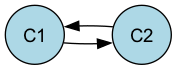

'summary_graph_t0.png'

In [131]:
S_t0, node_to_cluster_t0 = build_summary_graph(G_t0, clusters_t0)

print("Node to cluster mapping t0:")
print(node_to_cluster_t0)

print("\nSummary graph edges t0:")
print(list(S_t0.edges()))

print("\nVisualisasi Summary Graph t0")
show_graph(S_t0, "summary_graph_t0", "Summary Graph t0")

# Proses t1 satu per satu

## 16. t1 — Execution path

In [132]:
paths_t1 = extract_execution_paths(G_t1)
exit_t1 = get_exit_nodes(G_t1)

print("Exit nodes t1:", exit_t1)
print("\nExecution paths t1:")
print_paths(paths_t1)

Exit nodes t1: ['_make_timedelta', 'session_cookie_name', 'use_x_sendfile', '_check_setup_finished', 'name', 'propagate_exceptions', 'logger', 'got_first_request', 'make_config', 'make_aborter', 'auto_find_instance_path', 'open_instance_resource', 'templates_auto_reload', 'create_jinja_environment', 'create_global_jinja_loader', 'select_jinja_autoescape', 'update_template_context', 'make_shell_context', 'env', 'debug', 'run', 'test_client', 'test_cli_runner', 'register_blueprint', 'iter_blueprints', 'add_url_rule', 'template_filter', 'add_template_filter', 'template_test', 'add_template_test', 'template_global', 'add_template_global', 'before_first_request', 'teardown_appcontext', 'shell_context_processor', '_find_error_handler', 'trap_http_exception', 'log_exception', 'raise_routing_exception', 'make_default_options_response', 'should_ignore_error', 'async_to_sync', 'redirect', 'make_response', 'create_url_adapter', 'inject_url_defaults', 'handle_url_build_error', 'app_context', 'requ

## 17. t1 — Hitung `f(v)` dan normalisasi `f'(v)`

In [133]:
f_star_t1, f_t1, epl_t1, epl_norm_t1, indeg_t1, outdeg_t1, depth_t1, depth_norm_t1, pagerank_t1, pagerank_norm_t1, L_t1 = build_compact_behavior_feature_epl(
    G_t1, paths_t1)

print("L_t1 =", L_t1)

print("\nRaw f_path(v) t1:")
display(features_to_dataframe(f_t1, prefix="f"))

print("\nEPL(v) t1:")
display(pd.DataFrame.from_dict(epl_t1, orient="index", columns=["EPL"]))

print("\nEPL'(v) t1:")
display(pd.DataFrame.from_dict(epl_norm_t1, orient="index", columns=["EPL'"]))

print("\nIn-degree t1:")
display(pd.DataFrame.from_dict(indeg_t1, orient="index", columns=["indeg"]))

print("\nOut-degree t1:")
display(pd.DataFrame.from_dict(outdeg_t1, orient="index", columns=["outdeg"]))

print("\nDepth t1:")
display(pd.DataFrame.from_dict(depth_t1, orient="index", columns=["depth"]))

print("\nNormalized depth t1:")
display(pd.DataFrame.from_dict(depth_norm_t1, orient="index", columns=["depth'"]))

print("\nPageRank t1:")
display(pd.DataFrame.from_dict(pagerank_t1, orient="index", columns=["PageRank"]))

print("\nNormalized PageRank t1:")
display(pd.DataFrame.from_dict(pagerank_norm_t1, orient="index", columns=["PageRank'"]))

print("\nUpdated r+(v) t1 = [EPL', indeg', outdeg', depth', PageRank']:")
display(features_to_dataframe(f_star_t1, prefix="r"))

L_t1 = 6

Raw f_path(v) t1:


,f1,f2,f3,f4,f5,f6
iscoroutinefunction,0.0,0.0,0.0,0.0,0.0,0.0
_make_timedelta,1.0,0.0,0.0,0.0,0.0,0.0
session_cookie_name,0.0,0.0,0.0,0.0,0.0,0.0
send_file_max_age_default,1.0,0.0,0.0,0.0,0.0,0.0
use_x_sendfile,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
app_context,0.0,0.0,0.0,0.0,0.0,0.0
request_context,2.0,1.0,0.0,0.0,0.0,0.0
test_request_context,1.0,0.0,0.0,0.0,0.0,0.0
wsgi_app,2.0,4.0,10.0,12.0,7.0,3.0



EPL(v) t1:


,EPL
iscoroutinefunction,0.000000
_make_timedelta,1.000000
session_cookie_name,0.000000
send_file_max_age_default,1.000000
use_x_sendfile,0.000000
...,...
app_context,0.000000
request_context,1.333333
test_request_context,1.000000
wsgi_app,3.710526



EPL'(v) t1:


...

,PageRank
iscoroutinefunction,0.225063
_make_timedelta,0.016000
session_cookie_name,0.008648
send_file_max_age_default,0.008648
use_x_sendfile,0.008648
...,...
app_context,0.008648
request_context,0.019400
test_request_context,0.008648
wsgi_app,0.016000



Normalized PageRank t1:


,PageRank'
iscoroutinefunction,1.000000
_make_timedelta,0.071089
session_cookie_name,0.038426
send_file_max_age_default,0.038426
use_x_sendfile,0.038426
...,...
app_context,0.038426
request_context,0.086196
test_request_context,0.038426
wsgi_app,0.071089



Updated r+(v) t1 = [EPL', indeg', outdeg', depth', PageRank']:


,r1,r2,r3,r4,r5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.166667,0.111111,0.0,0.25,0.071089
session_cookie_name,0.000000,0.000000,0.0,0.00,0.038426
send_file_max_age_default,0.166667,0.000000,0.2,0.00,0.038426
use_x_sendfile,0.000000,0.000000,0.0,0.00,0.038426
...,...,...,...,...,...
app_context,0.000000,0.000000,0.0,0.00,0.038426
request_context,0.222222,0.222222,0.0,0.25,0.086196
test_request_context,0.166667,0.000000,0.2,0.00,0.038426
wsgi_app,0.618421,0.111111,0.8,0.25,0.071089


select active feature t1

In [134]:
# Select active behavioral-role features for t1
f_star_selected_t1 = select_behavior_features(
    f_star_t1,
    selected_features
)

print(f"\nSelected r(v) t1 for feature set: {ACTIVE_FEATURE_SET}")
display(features_to_dataframe(f_star_selected_t1, prefix="r_sel"))


Selected r(v) t1 for feature set: full_with_pagerank


,r_sel1,r_sel2,r_sel3,r_sel4,r_sel5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.166667,0.111111,0.0,0.25,0.071089
session_cookie_name,0.000000,0.000000,0.0,0.00,0.038426
send_file_max_age_default,0.166667,0.000000,0.2,0.00,0.038426
use_x_sendfile,0.000000,0.000000,0.0,0.00,0.038426
...,...,...,...,...,...
app_context,0.000000,0.000000,0.0,0.00,0.038426
request_context,0.222222,0.222222,0.0,0.25,0.086196
test_request_context,0.166667,0.000000,0.2,0.00,0.038426
wsgi_app,0.618421,0.111111,0.8,0.25,0.071089


## 18. t1 — Directed node2vec random walk dan embedding `e(v)`

In [135]:
e_t1, walks_t1, model_t1 = compute_directed_node2vec_embedding(
    G_t1,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t1:")
for w in walks_t1[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t1:")
display(features_to_dataframe(e_t1, prefix="e"))

Contoh 10 random walks t1:
open_instance_resource
make_default_options_response
template_filter
preprocess_request -> ensure_sync -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction -> iscoroutinefunction
name
env
add_template_global
create_global_jinja_loader
templates_auto_reload
should_ignore_error

Raw e(v) t1:


,e1,e2,e3,e4
iscoroutinefunction,-3.453952,2.680124,1.798574,0.438918
_make_timedelta,-5.712369,0.882377,-1.643310,1.528611
session_cookie_name,-0.041021,0.157010,-0.089392,-0.166514
send_file_max_age_default,-3.542038,-2.571193,1.345337,-1.731093
use_x_sendfile,0.064373,-0.207778,0.128744,-0.042096
...,...,...,...,...
app_context,-0.002187,-0.026922,-0.166893,-0.059489
request_context,-1.893412,1.849770,-1.991355,-5.154100
test_request_context,-2.366989,-1.732278,0.975628,-4.496508
wsgi_app,-0.617521,0.373365,0.837395,-1.991349


## 19. t1 — Normalisasi `e(v)` menjadi `e'(v)`

In [136]:
e_norm_t1 = normalize_e_l2(e_t1)

print("Normalized e'(v) t1:")
display(features_to_dataframe(e_norm_t1, prefix="e'"))

Normalized e'(v) t1:


,e'1,e'2,e'3,e'4
iscoroutinefunction,-0.727505,0.564514,0.378833,0.092449
_make_timedelta,-0.921268,0.142306,-0.265026,0.246528
session_cookie_name,-0.164673,0.630301,-0.358855,-0.668451
send_file_max_age_default,-0.723563,-0.525240,0.274824,-0.353626
use_x_sendfile,0.251213,-0.810850,0.502421,-0.164280
...,...,...,...,...
app_context,-0.012203,-0.150212,-0.931189,-0.331925
request_context,-0.309041,0.301918,-0.325027,-0.841247
test_request_context,-0.433789,-0.317468,0.178800,-0.824058
wsgi_app,-0.271129,0.163929,0.367666,-0.874321


## 20. t1 — Fusion menjadi `x(v)`

In [137]:
#x_t1 = fuse_features(e_norm_t1, f_star_t1, alpha=1.0, beta=1.0)
if ACTIVE_REPRESENTATION_MODE == "fused":
    x_t1 = fuse_features(e_norm_t1, f_star_selected_t1, alpha=1.0, beta=1.0)

elif ACTIVE_REPRESENTATION_MODE == "behavior_only":
    x_t1 = f_star_selected_t1

else:
    raise ValueError(f"Unknown representation mode: {ACTIVE_REPRESENTATION_MODE}")

print("Representation mode t1:", ACTIVE_REPRESENTATION_MODE)
print("Final x(v) t1:")
display(features_to_dataframe(x_t1, prefix="x"))

Representation mode t1: behavior_only
Final x(v) t1:


,x1,x2,x3,x4,x5
iscoroutinefunction,0.000000,0.222222,0.2,0.50,1.000000
_make_timedelta,0.166667,0.111111,0.0,0.25,0.071089
session_cookie_name,0.000000,0.000000,0.0,0.00,0.038426
send_file_max_age_default,0.166667,0.000000,0.2,0.00,0.038426
use_x_sendfile,0.000000,0.000000,0.0,0.00,0.038426
...,...,...,...,...,...
app_context,0.000000,0.000000,0.0,0.00,0.038426
request_context,0.222222,0.222222,0.0,0.25,0.086196
test_request_context,0.166667,0.000000,0.2,0.00,0.038426
wsgi_app,0.618421,0.111111,0.8,0.25,0.071089


## 21. t1 — Euclidean distance berdasarkan `x(v)`

In [138]:
nodes_t1, dist_t1 = compute_distance_matrix(x_t1)

dist_df_t1 = pd.DataFrame(dist_t1, index=nodes_t1, columns=nodes_t1)
print("Distance matrix t1:")
display(dist_df_t1.round(4))

Distance matrix t1:


,__call__,__init__,_check_setup_finished,_find_error_handler,_make_timedelta,add_template_filter,add_template_global,add_template_test,add_url_rule,app_context,...,template_test,templates_auto_reload,test_cli_runner,test_client,test_request_context,trap_http_exception,update_template_context,url_for,use_x_sendfile,wsgi_app
__call__,0.0000,1.3924,0.7297,0.8882,0.6342,0.6335,0.6335,0.6335,1.1570,0.7297,...,0.7297,0.7297,0.7297,0.7297,0.5351,1.0648,0.7297,0.6681,0.7297,0.6655
__init__,1.3924,0.0000,1.4284,1.0875,1.2502,1.2500,1.2500,1.2500,1.0000,1.4284,...,1.4284,1.4284,1.4284,1.4284,1.2855,1.0308,1.4284,1.0828,1.4284,0.8984
_check_setup_finished,0.7297,1.4284,0.0000,0.9278,0.3220,0.3205,0.3205,0.3205,1.0199,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.2603,1.0891,0.0000,0.6227,0.0000,1.0480
_find_error_handler,0.8882,1.0875,0.9278,0.0000,0.6075,0.6083,0.6083,0.6083,0.4274,0.9278,...,0.9278,0.9278,0.9278,0.9278,0.8860,0.3363,0.9278,1.0512,0.9278,0.9873
_make_timedelta,0.6342,1.2502,0.3220,0.6075,0.0000,0.0218,0.0218,0.0218,0.7504,0.3220,...,0.3220,0.3220,0.3220,0.3220,0.3405,0.7909,0.3220,0.6602,0.3220,0.9187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trap_http_exception,1.0648,1.0308,1.0891,0.3363,0.7909,0.7906,0.7906,0.7906,0.2500,1.0891,...,1.0891,1.0891,1.0891,1.0891,1.0559,0.0000,1.0891,1.1979,1.0891,1.1152
update_template_context,0.7297,1.4284,0.0000,0.9278,0.3220,0.3205,0.3205,0.3205,1.0199,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.2603,1.0891,0.0000,0.6227,0.0000,1.0480
url_for,0.6681,1.0828,0.6227,1.0512,0.6602,0.6595,0.6595,0.6595,1.1715,0.6227,...,0.6227,0.6227,0.6227,0.6227,0.4000,1.1979,0.6227,0.0000,0.6227,0.5657
use_x_sendfile,0.7297,1.4284,0.0000,0.9278,0.3220,0.3205,0.3205,0.3205,1.0199,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.2603,1.0891,0.0000,0.6227,0.0000,1.0480


## 22. t1 — Ward clustering

In [139]:
clusters_t1, Z_t1 = ward_clustering(x_t1, k=K_CLUSTERS)

print("Clusters t1:")
print_clusters(clusters_t1)

if Z_t1 is not None:
    print("\nWard linkage matrix t1:")
    display(pd.DataFrame(Z_t1, columns=["cluster_1", "cluster_2", "distance", "size"]))

if Z_t1 is not None:
    explain_ward_merges(Z_t1, sorted(x_t1.keys()))

Clusters t1:
C1: ['__call__', '_check_setup_finished', '_make_timedelta', 'add_template_filter', 'add_template_global', 'add_template_test', 'app_context', 'before_first_request', 'create_global_jinja_loader', 'create_jinja_environment', 'create_url_adapter', 'debug', 'decorator', 'do_teardown_appcontext', 'do_teardown_request', 'env', 'got_first_request', 'handle_url_build_error', 'inject_url_defaults', 'iter_blueprints', 'jinja_env', 'logger', 'make_shell_context', 'name', 'open_instance_resource', 'propagate_exceptions', 'redirect', 'register_blueprint', 'request_context', 'run', 'select_jinja_autoescape', 'send_file_max_age_default', 'session_cookie_name', 'shell_context_processor', 'teardown_appcontext', 'template_filter', 'template_global', 'template_test', 'templates_auto_reload', 'test_cli_runner', 'test_client', 'test_request_context', 'update_template_context', 'url_for', 'use_x_sendfile']
C2: ['__init__', '_find_error_handler', 'add_url_rule', 'async_to_sync', 'auto_find_ins

,cluster_1,cluster_2,distance,size
0,19.0,20.0,0.000000,2.0
1,33.0,52.0,0.000000,2.0
2,63.0,70.0,0.000000,3.0
3,5.0,6.0,0.000000,2.0
4,7.0,72.0,0.000000,3.0
...,...,...,...,...
63,21.0,31.0,1.263715,2.0
64,127.0,131.0,1.400038,45.0
65,128.0,132.0,1.704248,8.0
66,130.0,134.0,2.353589,24.0



Urutan merge Ward clustering:
Iterasi 1: merge ['do_teardown_appcontext'] + ['do_teardown_request'] -> ['do_teardown_appcontext', 'do_teardown_request']
  linkage distance = 0.0000, size = 2
Iterasi 2: merge ['jinja_env'] + ['send_file_max_age_default'] -> ['jinja_env', 'send_file_max_age_default']
  linkage distance = 0.0000, size = 2
Iterasi 3: merge ['test_request_context'] + ['jinja_env', 'send_file_max_age_default'] -> ['test_request_context', 'jinja_env', 'send_file_max_age_default']
  linkage distance = 0.0000, size = 3
Iterasi 4: merge ['add_template_filter'] + ['add_template_global'] -> ['add_template_filter', 'add_template_global']
  linkage distance = 0.0000, size = 2
Iterasi 5: merge ['add_template_test'] + ['add_template_filter', 'add_template_global'] -> ['add_template_test', 'add_template_filter', 'add_template_global']
  linkage distance = 0.0000, size = 3
Iterasi 6: merge ['create_url_adapter'] + ['add_template_test', 'add_template_filter', 'add_template_global'] -> [

## 23. t1 — Summary graph

Node to cluster mapping t1:
{'__call__': 1, '_check_setup_finished': 1, '_make_timedelta': 1, 'add_template_filter': 1, 'add_template_global': 1, 'add_template_test': 1, 'app_context': 1, 'before_first_request': 1, 'create_global_jinja_loader': 1, 'create_jinja_environment': 1, 'create_url_adapter': 1, 'debug': 1, 'decorator': 1, 'do_teardown_appcontext': 1, 'do_teardown_request': 1, 'env': 1, 'got_first_request': 1, 'handle_url_build_error': 1, 'inject_url_defaults': 1, 'iter_blueprints': 1, 'jinja_env': 1, 'logger': 1, 'make_shell_context': 1, 'name': 1, 'open_instance_resource': 1, 'propagate_exceptions': 1, 'redirect': 1, 'register_blueprint': 1, 'request_context': 1, 'run': 1, 'select_jinja_autoescape': 1, 'send_file_max_age_default': 1, 'session_cookie_name': 1, 'shell_context_processor': 1, 'teardown_appcontext': 1, 'template_filter': 1, 'template_global': 1, 'template_test': 1, 'templates_auto_reload': 1, 'test_cli_runner': 1, 'test_client': 1, 'test_request_context': 1, 'updat

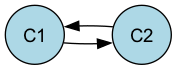

'summary_graph_t1.png'

In [140]:
S_t1, node_to_cluster_t1 = build_summary_graph(G_t1, clusters_t1)

print("Node to cluster mapping t1:")
print(node_to_cluster_t1)

print("\nSummary graph edges t1:")
print(list(S_t1.edges()))

print("\nVisualisasi Summary Graph t1")
show_graph(S_t1, "summary_graph_t1", "Summary Graph t1")

# 24. Rekap hasil t0 vs t1

In [141]:
recap = pd.DataFrame([
    {
        "version": "t0",
        "nodes": G_t0.number_of_nodes(),
        "edges": G_t0.number_of_edges(),
        "exit_nodes": exit_t0,
        "num_paths": len(paths_t0),
        "L": L_t0,
        "clusters": clusters_t0,
        "summary_edges": list(S_t0.edges())
    },
    {
        "version": "t1",
        "nodes": G_t1.number_of_nodes(),
        "edges": G_t1.number_of_edges(),
        "exit_nodes": exit_t1,
        "num_paths": len(paths_t1),
        "L": L_t1,
        "clusters": clusters_t1,
        "summary_edges": list(S_t1.edges())
    }
])

display(recap)

,version,nodes,edges,exit_nodes,num_paths,L,clusters,summary_edges
0,t0,65,47,"[_make_timedelta, _is_setup_finished, name, pr...",96,6,"{1: ['__call__', '_is_setup_finished', '_make_...","[(C1, C2), (C2, C1)]"
1,t1,69,46,"[_make_timedelta, session_cookie_name, use_x_s...",85,6,"{1: ['__call__', '_check_setup_finished', '_ma...","[(C1, C2), (C2, C1)]"


# 25. Optional: Jalankan pipeline sekaligus untuk satu file

Cell ini berguna nanti saat ingin menjalankan banyak test case.

In [ ]:
def run_full_pipeline(file_path, k=2, label="graph"):
    G, source = extract_call_graph_from_py(file_path)

    print("="*80)
    print(f"FILE: {file_path}")
    print("="*80)

    print("\n[1] Nodes and edges")
    print("Nodes:", list(G.nodes()))
    print("Edges:", list(G.edges()))

    print("\n[2] Execution paths")
    paths = extract_execution_paths(G)
    print_paths(paths)

    print("\n[3] f(v)")
    f, L = build_path_length_profile(G, paths)
    f_norm = normalize_f_l1(f)
    display(features_to_dataframe(f, prefix="f"))
    print("L =", L)

    print("\n[4] f'(v)")
    display(features_to_dataframe(f_norm, prefix="f'"))

    print("\n[5] directed node2vec walks and e(v)")
    e, walks, model = compute_directed_node2vec_embedding(
        G,
        dimensions=EMBED_DIM,
        walk_length=WALK_LENGTH,
        num_walks=NUM_WALKS,
        p=P_RETURN,
        q=Q_INOUT,
        seed=SEED
    )
    print("Sample walks:")
    for w in walks[:5]:
        print(" -> ".join(w))
    display(features_to_dataframe(e, prefix="e"))

    print("\n[6] e'(v)")
    e_norm = normalize_e_l2(e)
    display(features_to_dataframe(e_norm, prefix="e'"))

    print("\n[7] x(v)")
    f_norm_aligned = align_feature_dimensions(f_norm, L)
    x = fuse_features(e_norm, f_norm_aligned)
    display(features_to_dataframe(x, prefix="x"))

    print("\n[8] Distance matrix")
    nodes, dist = compute_distance_matrix(x)
    display(pd.DataFrame(dist, index=nodes, columns=nodes).round(4))

    print("\n[9] Ward clustering")
    clusters, Z = ward_clustering(x, k=k)
    print_clusters(clusters)

    print("\n[10] Summary graph")
    S, node_to_cluster = build_summary_graph(G, clusters)
    print("Node to cluster:", node_to_cluster)
    print("Summary edges:", list(S.edges()))

    return {
        "G": G,
        "source": source,
        "paths": paths,
        "f": f,
        "f_norm": f_norm,
        "L": L,
        "e": e,
        "e_norm": e_norm,
        "x": x,
        "clusters": clusters,
        "summary_graph": S,
        "node_to_cluster": node_to_cluster
    }

# Contoh pemakaian:
# result_t0 = run_full_pipeline(FILE_T0, k=K_CLUSTERS, label="t0")
# result_t1 = run_full_pipeline(FILE_T1, k=K_CLUSTERS, label="t1")

# 27. NPD Evaluation with Consistent Terminology

Section ini menghitung empat istilah NPD yang kita pakai:

1. **Original NPD**: neighbourhood-based NPD.
2. **EP-NPD**: proposed execution-path NPD sebelum clustering, tanpa proyeksi cluster.
3. **Cluster-EP-NPD compressed**: after clustering, path diproyeksikan ke cluster dan duplicate cluster berturut-turut dicompress.
4. **Cluster-EP-NPD uncompressed**: after clustering, path diproyeksikan ke cluster tetapi duplicate cluster dipertahankan.

Tujuan section ini adalah menghindari istilah yang membingungkan seperti “projected before”. Before clustering menggunakan **EP-NPD non-projected**.

## 27.1 Terminology Table

Tabel ini merangkum istilah yang dipakai dalam section NPD.

In [ ]:
npd_terms = pd.DataFrame([
    {
        "Istilah": "Original NPD",
        "Dipakai kapan": "Before / after",
        "Unit path": "shortest-path neighbourhood",
        "Ada proyeksi cluster?": "Tidak khusus",
        "Makna ringkas": "Divergence struktur neighbourhood graph."
    },
    {
        "Istilah": "EP-NPD",
        "Dipakai kapan": "Before clustering",
        "Unit path": "function-level execution path",
        "Ada proyeksi cluster?": "Tidak",
        "Makna ringkas": "Divergence distribusi panjang execution path antar fungsi."
    },
    {
        "Istilah": "Cluster-EP-NPD compressed",
        "Dipakai kapan": "After clustering",
        "Unit path": "cluster-projected execution path",
        "Ada proyeksi cluster?": "Ya, duplicate cluster berturut-turut dicompress",
        "Makna ringkas": "Mengukur divergence transisi execution flow antarcluster."
    },
    {
        "Istilah": "Cluster-EP-NPD uncompressed",
        "Dipakai kapan": "After clustering",
        "Unit path": "cluster-projected execution path",
        "Ada proyeksi cluster?": "Ya, duplicate cluster dipertahankan",
        "Makna ringkas": "Diagnostic/control untuk melihat preservation panjang path internal."
    },
])

display(npd_terms.style.hide(axis="index"))

## 27.2 NPD Utility Functions

Cell ini berisi fungsi untuk:
- Original NPD,
- EP-NPD function-level sebelum clustering,
- Cluster-EP-NPD compressed/uncompressed setelah clustering.

In [142]:
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import networkx as nx

# ============================================================
# Jensen-Shannon Divergence
# ============================================================

def align_distributions(p1, p2):
    keys = sorted(set(p1) | set(p2))
    P = np.array([p1.get(k, 0.0) for k in keys])
    Q = np.array([p2.get(k, 0.0) for k in keys])
    return P, Q, keys


def compute_jsd(P, Q):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    if P.sum() == 0 and Q.sum() == 0:
        return 0.0

    if P.sum() > 0:
        P = P / P.sum()
    if Q.sum() > 0:
        Q = Q / Q.sum()

    M = 0.5 * (P + Q)

    def kl_div(A, B):
        mask = A > 0
        return np.sum(A[mask] * np.log2(A[mask] / B[mask]))

    return 0.5 * kl_div(P, M) + 0.5 * kl_div(Q, M)


# ============================================================
# 1. Original NPD: neighbourhood portrait
#    (unchanged from the original formulation)
# ============================================================

def compute_network_portrait_npd(G):
    """
    Original NPD baseline using neighbourhood portrait.

    l = shortest-path distance
    k = number of nodes at distance l

    Output:
        {(l, k): probability}
    """
    portrait = defaultdict(lambda: defaultdict(int))

    for node in G.nodes:
        lengths = nx.single_source_shortest_path_length(G, node)

        count_by_distance = defaultdict(int)
        for target, dist in lengths.items():
            if target != node:
                count_by_distance[dist] += 1

        for l, k in count_by_distance.items():
            portrait[l][k] += 1

    flat = defaultdict(int)
    total = 0

    for l in portrait:
        for k in portrait[l]:
            flat[(l, k)] += portrait[l][k]
            total += portrait[l][k]

    if total == 0:
        return {}

    return {key: val / total for key, val in flat.items()}


def compute_original_npd(G1, G2):
    portrait_1 = compute_network_portrait_npd(G1)
    portrait_2 = compute_network_portrait_npd(G2)

    P, Q, keys = align_distributions(portrait_1, portrait_2)
    value = compute_jsd(P, Q)

    return {
        "value": value,
        "portrait_1": portrait_1,
        "portrait_2": portrait_2,
        "P": P,
        "Q": Q,
        "keys": keys
    }


# ============================================================
# Execution paths
# ============================================================

def enumerate_execution_paths_for_npd(G, entry_nodes=None, max_length=None):
    """
    Wrapper for NPD execution path enumeration.

    If entry_nodes is None, use the same execution-path definition
    as EPL construction: all non-exit nodes to exit nodes.
    """
    if entry_nodes is None:
        paths = extract_execution_paths(G)
    else:
        paths = []
        for src in entry_nodes:
            for end in get_exit_nodes(G):
                if src == end:
                    continue
                try:
                    for path in nx.all_simple_paths(G, src, end, cutoff=max_length):
                        if len(path) > 1:
                            paths.append(path)
                except nx.NetworkXNoPath:
                    pass

        seen = set()
        unique_paths = []
        for p in paths:
            key = tuple(p)
            if key not in seen:
                seen.add(key)
                unique_paths.append(p)
        paths = unique_paths

    if max_length is not None:
        paths = [p for p in paths if len(p) - 1 <= max_length]

    return paths


# ============================================================
# 2. EP-NPD before clustering: function-level execution path
# ============================================================

def compute_execution_path_portrait_npd(G, entry_nodes=None, max_length=None):
    """
    EP-NPD portrait before clustering, using node-level execution path portrait.

    l = execution path length at function-node level
    k = number of execution paths with length l starting from a node

    Output:
        {(l, k): probability}

    For each path length l, the portrait counts how many nodes have k
    outgoing execution paths of length l.
    """
    paths = enumerate_execution_paths_for_npd(
        G,
        entry_nodes=entry_nodes,
        max_length=max_length
    )

    if not paths:
        return {}, paths

    # Maximum function-level execution path length
    L = max(len(p) - 1 for p in paths if len(p) > 1)

    if L == 0:
        return {}, paths

    # node_length_counts[v][l] = number of execution paths
    # starting from node v with length l
    node_length_counts = {
        v: Counter()
        for v in G.nodes()
    }

    for p in paths:
        if len(p) <= 1:
            continue

        start_node = p[0]
        l = len(p) - 1

        if start_node in node_length_counts:
            node_length_counts[start_node][l] += 1

    # Build portrait:
    # portrait_counts[(l, k)] = number of nodes that have k paths of length l
    portrait_counts = Counter()

    for l in range(1, L + 1):
        for v in G.nodes():
            k = node_length_counts[v].get(l, 0)
            portrait_counts[(l, k)] += 1

    total = sum(portrait_counts.values())

    if total == 0:
        return {}, paths

    portrait = {
        key: count / total
        for key, count in sorted(portrait_counts.items())
    }

    return portrait, paths


def compute_ep_npd(G1, G2):
    """
    Proposed EP-NPD before clustering.
    No cluster projection is used here.

    Portrait definition:
        l = function-level execution path length
        k = number of paths with length l starting from a node
    """
    portrait_1, paths_1 = compute_execution_path_portrait_npd(G1)
    portrait_2, paths_2 = compute_execution_path_portrait_npd(G2)

    P, Q, keys = align_distributions(portrait_1, portrait_2)
    value = compute_jsd(P, Q)

    return {
        "value": value,
        "portrait_1": portrait_1,
        "portrait_2": portrait_2,
        "P": P,
        "Q": Q,
        "keys": keys,
        "paths_1": paths_1,
        "paths_2": paths_2
    }


# ============================================================
# 3. Cluster-EP-NPD after clustering
# ============================================================

def compress_consecutive_duplicates(seq):
    """
    Compress consecutive duplicate cluster labels.

    Example:
        [C1, C2, C2, C3, C3] -> [C1, C2, C3]
    """
    if not seq:
        return seq

    compressed = [seq[0]]

    for item in seq[1:]:
        if item != compressed[-1]:
            compressed.append(item)

    return compressed


def project_execution_path_to_cluster(path, node_to_cluster, compressed=True):
    """
    Project one function-level execution path to a cluster-level path.

    compressed=True:
        consecutive duplicate clusters are removed.

    compressed=False:
        consecutive duplicate clusters are preserved.
    """
    projected = [node_to_cluster[v] for v in path if v in node_to_cluster]

    if compressed:
        projected = compress_consecutive_duplicates(projected)

    return projected


def compute_cluster_execution_path_portrait_npd(G, node_to_cluster, compressed=True):
    """
    Cluster-EP-NPD portrait after clustering, using node-level cluster path portrait.

    lc = cluster-projected execution path length
    k  = number of projected execution paths with length lc starting from a node

    Output:
        {(lc, k): probability}

    compressed=True:
        C1 -> C2 -> C2 -> C3 becomes C1 -> C2 -> C3.

    compressed=False:
        C1 -> C2 -> C2 -> C3 remains unchanged.

    For each cluster-level path length lc, the portrait counts how many
    original function nodes have k outgoing projected execution paths
    with that cluster-level length.
    """
    paths = enumerate_execution_paths_for_npd(G)

    projected_paths = []

    # node_cluster_length_counts[v][lc] =
    # number of original execution paths starting from node v
    # whose projected cluster-level length is lc
    node_cluster_length_counts = {
        v: Counter()
        for v in G.nodes()
    }

    max_lc = 0

    for p in paths:
        if len(p) <= 1:
            continue

        start_node = p[0]

        pp = project_execution_path_to_cluster(
            p,
            node_to_cluster=node_to_cluster,
            compressed=compressed
        )

        # For compressed projection, len(pp) can become 1.
        # That means the whole path is absorbed inside one cluster.
        # We keep it as lc = 0.
        if len(pp) == 0:
            continue

        lc = len(pp) - 1
        max_lc = max(max_lc, lc)

        projected_paths.append(pp)

        if start_node in node_cluster_length_counts:
            node_cluster_length_counts[start_node][lc] += 1

    if not projected_paths:
        return {}, projected_paths

    portrait_counts = Counter()

    # Include lc = 0 because it has meaning:
    # the original path is fully absorbed inside one cluster.
    min_lc = 0 if compressed else 1

    for lc in range(min_lc, max_lc + 1):
        for v in G.nodes():
            k = node_cluster_length_counts[v].get(lc, 0)
            portrait_counts[(lc, k)] += 1

    total = sum(portrait_counts.values())

    if total == 0:
        return {}, projected_paths

    portrait = {
        key: count / total
        for key, count in sorted(portrait_counts.items())
    }

    return portrait, projected_paths

def compute_cluster_ep_npd(G1, G2, node_to_cluster_1, node_to_cluster_2, compressed=True):
    """
    Cluster-EP-NPD after clustering.

    The original execution paths are preserved as the evaluation basis,
    but each function node is projected to its Ward cluster.

    Portrait definition:
        lc = cluster-projected execution path length
        k  = number of projected execution paths with length lc
             starting from a function node
    """
    portrait_1, projected_paths_1 = compute_cluster_execution_path_portrait_npd(
        G1,
        node_to_cluster=node_to_cluster_1,
        compressed=compressed
    )
    portrait_2, projected_paths_2 = compute_cluster_execution_path_portrait_npd(
        G2,
        node_to_cluster=node_to_cluster_2,
        compressed=compressed
    )

    P, Q, keys = align_distributions(portrait_1, portrait_2)
    value = compute_jsd(P, Q)

    return {
        "value": value,
        "portrait_1": portrait_1,
        "portrait_2": portrait_2,
        "P": P,
        "Q": Q,
        "keys": keys,
        "projected_paths_1": projected_paths_1,
        "projected_paths_2": projected_paths_2
    }

def print_portrait(title, portrait):
    print(title)

    if not portrait:
        print("  <empty>")
        return

    for key, val in sorted(portrait.items()):
        print(f"  {key}: {val:.3f}")


print("NPD utility functions ready.")

NPD utility functions ready.


Dual-length NPD

In [143]:
def compress_consecutive_duplicates(seq):
    """
    Compress consecutive duplicate cluster ids.

    Example:
    [1, 1, 2, 2, 2] -> [1, 2]
    [2, 2] -> [2]
    """
    if not seq:
        return []

    compressed = [seq[0]]

    for item in seq[1:]:
        if item != compressed[-1]:
            compressed.append(item)

    return compressed

from collections import Counter

def compute_dual_length_cluster_ep_portrait(paths, node_to_cluster, graph_nodes=None):
    """
    Dual-Length Cluster-EP-NPD portrait using node-level path distribution.

    Portrait:
        P(lo, lc, k)

    where:
        lo = original function-level execution path length
        lc = compressed cluster-level execution path length
        k  = number of paths with the same (lo, lc) starting from a node

    Important:
        Paths with lc = 0 are kept.
        This captures paths fully absorbed inside one cluster.

    Output:
        portrait:
            {(lo, lc, k): probability}

        detail_rows:
            detailed projection information for debugging.
    """

    if graph_nodes is None:
        graph_nodes = sorted(node_to_cluster.keys())
    else:
        graph_nodes = sorted(graph_nodes)

    # node_pair_counts[v][(lo, lc)] =
    # number of paths starting from node v with pair (lo, lc)
    node_pair_counts = {
        v: Counter()
        for v in graph_nodes
    }

    observed_pairs = set()
    detail_rows = []

    for p in paths:
        if len(p) <= 1:
            continue

        start_node = p[0]

        # original function-level path length
        lo = len(p) - 1

        # project function nodes to cluster ids
        cluster_path = [
            node_to_cluster[v]
            for v in p
            if v in node_to_cluster
        ]

        # safety check: skip if projection failed
        if len(cluster_path) != len(p):
            continue

        # compressed cluster path
        compressed_cluster_path = compress_consecutive_duplicates(cluster_path)

        # compressed cluster-level path length
        # if compressed path is [C1], then lc = 0
        lc = len(compressed_cluster_path) - 1

        pair = (lo, lc)
        observed_pairs.add(pair)

        if start_node in node_pair_counts:
            node_pair_counts[start_node][pair] += 1

        detail_rows.append({
            "original_path": p,
            "start_node": start_node,
            "lo": lo,
            "cluster_path": cluster_path,
            "compressed_cluster_path": compressed_cluster_path,
            "lc": lc,
            "bucket": pair
        })

    if not observed_pairs:
        return {}, detail_rows

    # Build portrait:
    # portrait_counts[(lo, lc, k)] =
    # number of nodes that have k paths with pair (lo, lc)
    portrait_counts = Counter()

    for pair in sorted(observed_pairs):
        lo, lc = pair

        for v in graph_nodes:
            k = node_pair_counts[v].get(pair, 0)
            portrait_counts[(lo, lc, k)] += 1

    total = sum(portrait_counts.values())

    if total == 0:
        return {}, detail_rows

    portrait = {
        key: count / total
        for key, count in sorted(portrait_counts.items())
    }

    return portrait, detail_rows

def compute_dual_length_cluster_ep_npd(
    paths_1,
    paths_2,
    node_to_cluster_1,
    node_to_cluster_2,
    graph_nodes_1=None,
    graph_nodes_2=None
):
    """
    Compute Dual-Length Cluster-EP-NPD between two clustered versions.

    Input:
        paths_1, paths_2:
            validated function-level execution paths

        node_to_cluster_1, node_to_cluster_2:
            mapping from original function node to Ward cluster id

        graph_nodes_1, graph_nodes_2:
            complete function-node lists from each graph.
            These are used to include nodes with k = 0 in the portrait.

    Portrait definition:
        P(lo, lc, k)

    where:
        lo = original function-level execution path length
        lc = compressed cluster-level execution path length
        k  = number of paths with the same (lo, lc) starting from a node

    Output:
        JSD value and portraits.
    """

    portrait_1, details_1 = compute_dual_length_cluster_ep_portrait(
        paths_1,
        node_to_cluster_1,
        graph_nodes=graph_nodes_1
    )

    portrait_2, details_2 = compute_dual_length_cluster_ep_portrait(
        paths_2,
        node_to_cluster_2,
        graph_nodes=graph_nodes_2
    )

    P, Q, keys = align_distributions(portrait_1, portrait_2)
    value = compute_jsd(P, Q)

    return {
        "value": value,
        "portrait_1": portrait_1,
        "portrait_2": portrait_2,
        "P": P,
        "Q": Q,
        "keys": keys,
        "details_1": details_1,
        "details_2": details_2
    }

print("Dual-length NPD utility functions ready.")

Dual-length NPD utility functions ready.


## 27.3 Before Ward Clustering

Sebelum Ward clustering, kita menghitung:

1. **Original NPD** pada \(G_{t0}\) vs \(G_{t1}\).
2. **EP-NPD** pada function-level execution path, tanpa proyeksi cluster.

In [144]:
npd_original_before = compute_original_npd(G_t0, G_t1)
npd_ep_before = compute_ep_npd(G_t0, G_t1)

print("=== BEFORE WARD CLUSTERING: G_t0 vs G_t1 ===")
print("Original NPD before Ward (JSD):", round(npd_original_before["value"], 6))
print("EP-NPD before Ward (JSD):", round(npd_ep_before["value"], 6))

print("\nOriginal portrait G_t0:")
print_portrait("G_t0:", npd_original_before["portrait_1"])

print("\nOriginal portrait G_t1:")
print_portrait("G_t1:", npd_original_before["portrait_2"])

print("\nExecution-path portrait G_t0:")
print_portrait("G_t0:", npd_ep_before["portrait_1"])

print("\nExecution-path portrait G_t1:")
print_portrait("G_t1:", npd_ep_before["portrait_2"])

print("\nSample function-level execution paths t0:")
for p in npd_ep_before["paths_1"][:10]:
    print(p)

=== BEFORE WARD CLUSTERING: G_t0 vs G_t1 ===
Original NPD before Ward (JSD): 0.155238
EP-NPD before Ward (JSD): 0.020402

Original portrait G_t0:
G_t0:
  (1, 1): 0.184
  (1, 2): 0.158
  (1, 3): 0.079
  (1, 4): 0.079
  (1, 5): 0.026
  (2, 2): 0.184
  (2, 3): 0.053
  (2, 4): 0.026
  (2, 5): 0.026
  (2, 8): 0.026
  (2, 9): 0.026
  (3, 2): 0.053
  (3, 8): 0.026
  (3, 9): 0.026
  (4, 9): 0.026

Original portrait G_t1:
G_t1:
  (1, 1): 0.229
  (1, 2): 0.086
  (1, 3): 0.086
  (1, 4): 0.114
  (1, 5): 0.029
  (2, 1): 0.029
  (2, 2): 0.200
  (2, 4): 0.057
  (2, 7): 0.029
  (2, 9): 0.029
  (3, 2): 0.029
  (3, 7): 0.029
  (3, 8): 0.029
  (4, 8): 0.029

Execution-path portrait G_t0:
G_t0:
  (1, 0): 0.128
  (1, 1): 0.028
  (1, 2): 0.005
  (1, 3): 0.005
  (2, 0): 0.133
  (2, 1): 0.021
  (2, 2): 0.008
  (2, 3): 0.003
  (2, 5): 0.003
  (3, 0): 0.151
  (3, 1): 0.008
  (3, 2): 0.003
  (3, 6): 0.003
  (3, 8): 0.003
  (4, 0): 0.156
  (4, 1): 0.003
  (4, 3): 0.003
  (4, 7): 0.003
  (4, 8): 0.003
  (5, 0): 0.

## 27.4 After Ward Clustering at Current `K_CLUSTERS`

Setelah Ward clustering, kita menghitung:

1. **Original NPD** pada summary graph \(S_{t0}\) vs \(S_{t1}\).
2. **Cluster-EP-NPD compressed**.
3. **Cluster-EP-NPD uncompressed**.

In [145]:
npd_original_after = compute_original_npd(S_t0, S_t1)

npd_cluster_ep_after_compressed = compute_cluster_ep_npd(
    G_t0,
    G_t1,
    node_to_cluster_1=node_to_cluster_t0,
    node_to_cluster_2=node_to_cluster_t1,
    compressed=True
)

npd_cluster_ep_after_uncompressed = compute_cluster_ep_npd(
    G_t0,
    G_t1,
    node_to_cluster_1=node_to_cluster_t0,
    node_to_cluster_2=node_to_cluster_t1,
    compressed=False
)

npd_dual_length_after = compute_dual_length_cluster_ep_npd(
    paths_t0,
    paths_t1,
    node_to_cluster_t0,
    node_to_cluster_t1,
    graph_nodes_1=list(G_t0.nodes()),
    graph_nodes_2=list(G_t1.nodes())
)

print(f"=== AFTER WARD CLUSTERING at K_CLUSTERS = {K_CLUSTERS} ===")
print("Original NPD on summary graph (JSD):", round(npd_original_after["value"], 6))
print("Cluster-EP-NPD compressed after Ward (JSD):", round(npd_cluster_ep_after_compressed["value"], 6))
print("Cluster-EP-NPD uncompressed after Ward (JSD):", round(npd_cluster_ep_after_uncompressed["value"], 6))
print("Dual-Length Cluster-EP-NPD after Ward (JSD):", round(npd_dual_length_after["value"], 6))

print("\nCompressed cluster-projected portrait t0:")
print_portrait("t0:", npd_cluster_ep_after_compressed["portrait_1"])

print("\nCompressed cluster-projected portrait t1:")
print_portrait("t1:", npd_cluster_ep_after_compressed["portrait_2"])

print("\nUncompressed cluster-projected portrait t0:")
print_portrait("t0:", npd_cluster_ep_after_uncompressed["portrait_1"])

print("\nUncompressed cluster-projected portrait t1:")
print_portrait("t1:", npd_cluster_ep_after_uncompressed["portrait_2"])

print("\nSample compressed cluster-projected paths t0:")
for p in npd_cluster_ep_after_compressed["projected_paths_1"][:10]:
    print(p)

print("\nSample uncompressed cluster-projected paths t0:")
for p in npd_cluster_ep_after_uncompressed["projected_paths_1"][:10]:
    print(p)

print("\nDual-Length Cluster-EP-NPD portrait t0:")
print_portrait("t0:", npd_dual_length_after["portrait_1"])

print("\nDual-Length Cluster-EP-NPD portrait t1:")
print_portrait("t1:", npd_dual_length_after["portrait_2"])

=== AFTER WARD CLUSTERING at K_CLUSTERS = 2 ===
Original NPD on summary graph (JSD): 0.0
Cluster-EP-NPD compressed after Ward (JSD): 0.037964
Cluster-EP-NPD uncompressed after Ward (JSD): 0.020402
Dual-Length Cluster-EP-NPD after Ward (JSD): 0.297962

Compressed cluster-projected portrait t0:
t0:
  (0, 0): 0.262
  (0, 1): 0.041
  (0, 2): 0.010
  (0, 3): 0.010
  (0, 4): 0.005
  (0, 5): 0.005
  (1, 0): 0.272
  (1, 1): 0.015
  (1, 2): 0.021
  (1, 4): 0.005
  (1, 5): 0.010
  (1, 10): 0.005
  (1, 17): 0.005
  (2, 0): 0.328
  (2, 17): 0.005

Compressed cluster-projected portrait t1:
t1:
  (0, 0): 0.256
  (0, 1): 0.029
  (0, 2): 0.010
  (0, 3): 0.014
  (0, 4): 0.005
  (0, 5): 0.010
  (0, 12): 0.005
  (0, 18): 0.005
  (1, 0): 0.314
  (1, 1): 0.014
  (1, 18): 0.005
  (2, 0): 0.329
  (2, 1): 0.005

Uncompressed cluster-projected portrait t0:
t0:
  (1, 0): 0.128
  (1, 1): 0.028
  (1, 2): 0.005
  (1, 3): 0.005
  (2, 0): 0.133
  (2, 1): 0.021
  (2, 2): 0.008
  (2, 3): 0.003
  (2, 5): 0.003
  (3, 0)

## 27.5 Summary Table for Current `K_CLUSTERS`

Tabel ini menampilkan hasil NPD pada nilai `K_CLUSTERS` yang sedang dipakai.

In [146]:
npd_current_k_table = pd.DataFrame([
    {
        "Stage": "Before Ward",
        "Metric": "Original NPD",
        "Portrait": "P(l,k)",
        "JSD": npd_original_before["value"]
    },
    {
        "Stage": "Before Ward",
        "Metric": "EP-NPD",
        "Portrait": "P(l,k)",
        "JSD": npd_ep_before["value"]
    },
    {
        "Stage": "After Ward",
        "Metric": "Original NPD",
        "Portrait": "P(l,k)",
        "JSD": npd_original_after["value"]
    },
    {
        "Stage": "After Ward",
        "Metric": "Cluster-EP-NPD compressed",
        "Portrait": "P(l_c,k)",
        "JSD": npd_cluster_ep_after_compressed["value"]
    },
    {
        "Stage": "After Ward",
        "Metric": "Cluster-EP-NPD uncompressed",
        "Portrait": "P(l_o,k)",
        "JSD": npd_cluster_ep_after_uncompressed["value"]
    },
    {
        "Stage": "After Ward",
        "Metric": "Dual-Length Cluster-EP-NPD",
        "Portrait": "P(l_o,l_c,k)",
        "JSD": npd_dual_length_after["value"]
    },
])

display(
    npd_current_k_table
    .style
    .hide(axis="index")
    .format({"JSD": "{:.6f}"})
)

Stage,Metric,Portrait,JSD
Before Ward,Original NPD,"P(l,k)",0.155238
Before Ward,EP-NPD,"P(l,k)",0.020402
After Ward,Original NPD,"P(l,k)",0.000000
After Ward,Cluster-EP-NPD compressed,"P(l_c,k)",0.037964
After Ward,Cluster-EP-NPD uncompressed,"P(l_o,k)",0.020402
After Ward,Dual-Length Cluster-EP-NPD,"P(l_o,l_c,k)",0.297962


## 27.6 Multi-Resolution Evaluation over \(k\)

Cell ini menjalankan sweep untuk beberapa nilai \(k\), tanpa mengubah variabel global `K_CLUSTERS`.

Tujuannya adalah melihat bagaimana hasil NPD setelah Ward berubah pada berbagai resolusi cluster.

In [147]:
from collections import Counter

def compute_execution_path_portrait_from_paths(paths, graph_nodes):
    """
    Build EP-NPD portrait from validated execution paths.

    Portrait:
        P(l, k)

    where:
        l = function-level execution path length
        k = number of execution paths with length l starting from a node

    The portrait counts how many nodes have k paths of length l.
    """
    graph_nodes = sorted(graph_nodes)

    valid_paths = [
        p for p in paths
        if len(p) > 1
    ]

    if not valid_paths:
        return {}

    L = max(len(p) - 1 for p in valid_paths)

    if L == 0:
        return {}

    node_length_counts = {
        v: Counter()
        for v in graph_nodes
    }

    for p in valid_paths:
        start_node = p[0]
        l = len(p) - 1

        if start_node in node_length_counts:
            node_length_counts[start_node][l] += 1

    portrait_counts = Counter()

    for l in range(1, L + 1):
        for v in graph_nodes:
            k = node_length_counts[v].get(l, 0)
            portrait_counts[(l, k)] += 1

    total = sum(portrait_counts.values())

    if total == 0:
        return {}

    portrait = {
        key: count / total
        for key, count in sorted(portrait_counts.items())
    }

    return portrait


def compute_ep_npd_from_paths(paths_1, paths_2, graph_nodes_1, graph_nodes_2):
    """
    Compute proposed EP-NPD before clustering using already validated paths.

    This avoids re-enumerating paths from the graph and keeps EP-NPD
    consistent with the selected execution-path enumeration policy.
    """
    portrait_1 = compute_execution_path_portrait_from_paths(
        paths_1,
        graph_nodes_1
    )

    portrait_2 = compute_execution_path_portrait_from_paths(
        paths_2,
        graph_nodes_2
    )

    P, Q, keys = align_distributions(portrait_1, portrait_2)
    value = compute_jsd(P, Q)

    return {
        "value": value,
        "portrait_1": portrait_1,
        "portrait_2": portrait_2,
        "P": P,
        "Q": Q,
        "keys": keys,
        "paths_1": paths_1,
        "paths_2": paths_2
    }

In [148]:
# ============================================================
# Multi-resolution NPD evaluation over k
# ============================================================

def evaluate_npd_over_k(G0, G1, x0, x1, paths0, paths1, k_values):
    """
    Evaluate NPD variants over multiple Ward clustering resolutions.

    Important:
    - EP-NPD before uses validated execution paths: paths0, paths1.
    - EP-NPD before is built as node-level portrait P(l,k).
    - Dual-Length Cluster-EP-NPD also uses validated paths0, paths1.
    - Dual-Length Cluster-EP-NPD is built as node-level portrait P(lo,lc,k).
    - Cluster-EP compressed/uncompressed are kept as baseline/diagnostic.
    """

    rows = []

    graph_nodes0 = list(G0.nodes())
    graph_nodes1 = list(G1.nodes())

    # Before clustering
    original_before = compute_original_npd(G0, G1)
    ep_before = compute_ep_npd_from_paths(
        paths0,
        paths1,
        graph_nodes_1=graph_nodes0,
        graph_nodes_2=graph_nodes1
    )

    for k in k_values:
        # 1. Ward clustering at resolution k
        clusters0, _ = ward_clustering(x0, k=k)
        clusters1, _ = ward_clustering(x1, k=k)

        # 2. Build summary graph and node-to-cluster mapping
        S0, node_to_cluster0 = build_summary_graph(G0, clusters0)
        S1, node_to_cluster1 = build_summary_graph(G1, clusters1)

        # 3. Original NPD after Ward, on summary graph
        original_after = compute_original_npd(S0, S1)

        # 4. Cluster-EP-NPD compressed, baseline/diagnostic
        cluster_ep_compressed = compute_cluster_ep_npd(
            G0,
            G1,
            node_to_cluster_1=node_to_cluster0,
            node_to_cluster_2=node_to_cluster1,
            compressed=True
        )

        # 5. Cluster-EP-NPD uncompressed, diagnostic/control
        cluster_ep_uncompressed = compute_cluster_ep_npd(
            G0,
            G1,
            node_to_cluster_1=node_to_cluster0,
            node_to_cluster_2=node_to_cluster1,
            compressed=False
        )

        # 6. Dual-Length Cluster-EP-NPD, proposed after-clustering metric
        dual_length_after = compute_dual_length_cluster_ep_npd(
            paths0,
            paths1,
            node_to_cluster0,
            node_to_cluster1,
            graph_nodes_1=graph_nodes0,
            graph_nodes_2=graph_nodes1
        )

        rows.append({
            "k": k,

            "S0_nodes": S0.number_of_nodes(),
            "S0_edges": S0.number_of_edges(),
            "S1_nodes": S1.number_of_nodes(),
            "S1_edges": S1.number_of_edges(),

            "Original before": original_before["value"],
            "Original after": original_after["value"],
            "Original gap": abs(original_before["value"] - original_after["value"]),

            "EP before": ep_before["value"],

            "Cluster-EP compressed after": cluster_ep_compressed["value"],
            "Compressed gap": abs(ep_before["value"] - cluster_ep_compressed["value"]),

            "Cluster-EP uncompressed after": cluster_ep_uncompressed["value"],
            "Uncompressed gap": abs(ep_before["value"] - cluster_ep_uncompressed["value"]),

            "Dual-Length Cluster-EP after": dual_length_after["value"],
            "Dual-Length gap": abs(ep_before["value"] - dual_length_after["value"]),
        })

    return pd.DataFrame(rows)

In [149]:
# ============================================================
# Run multi-resolution evaluation
# ============================================================

k_values = list(range(2, 16))

npd_over_k = evaluate_npd_over_k(
    G_t0,
    G_t1,
    x_t0,
    x_t1,
    paths_t0,
    paths_t1,
    k_values
)

# ============================================================
# Display table
# ============================================================

_format_cols = {
    "Original before": "{:.6f}",
    "Original after": "{:.6f}",
    "Original gap": "{:.6f}",

    "EP before": "{:.6f}",

    "Cluster-EP compressed after": "{:.6f}",
    "Compressed gap": "{:.6f}",

    "Cluster-EP uncompressed after": "{:.6f}",
    "Uncompressed gap": "{:.6f}",

    "Dual-Length Cluster-EP after": "{:.6f}",
    "Dual-Length gap": "{:.6f}",
}

display(
    npd_over_k
    .style
    .hide(axis="index")
    .format(_format_cols)
)

# ============================================================
# Best-k analysis
# ============================================================

print("Best k by compressed Cluster-EP gap:")
display(
    npd_over_k
    .sort_values("Compressed gap")
    .head(5)
    .style
    .hide(axis="index")
    .format(_format_cols)
)

print("Best k by uncompressed Cluster-EP gap:")
display(
    npd_over_k
    .sort_values("Uncompressed gap")
    .head(5)
    .style
    .hide(axis="index")
    .format(_format_cols)
)

print("Best k by Dual-Length Cluster-EP gap:")
display(
    npd_over_k
    .sort_values("Dual-Length gap")
    .head(5)
    .style
    .hide(axis="index")
    .format(_format_cols)
)

print("Best k by Original NPD gap:")
display(
    npd_over_k
    .sort_values("Original gap")
    .head(5)
    .style
    .hide(axis="index")
    .format(_format_cols)
)

k,S0_nodes,S0_edges,S1_nodes,S1_edges,Original before,Original after,Original gap,EP before,Cluster-EP compressed after,Compressed gap,Cluster-EP uncompressed after,Uncompressed gap,Dual-Length Cluster-EP after,Dual-Length gap
2,2,2,2,2,0.155238,0.000000,0.155238,0.020402,0.037964,0.017562,0.020402,0.000000,0.297962,0.277560
3,3,4,3,4,0.155238,0.000000,0.155238,0.020402,0.160812,0.140410,0.020402,0.000000,0.202697,0.182295
4,4,4,4,7,0.155238,0.124511,0.030727,0.020402,0.146890,0.126488,0.020402,0.000000,0.200812,0.180410
5,5,7,5,8,0.155238,0.259910,0.104672,0.020402,0.026978,0.006576,0.020402,0.000000,0.087123,0.066721
6,6,8,6,9,0.155238,0.173766,0.018528,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
7,7,9,7,9,0.155238,0.035016,0.120222,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
8,8,11,8,11,0.155238,0.112481,0.042758,0.020402,0.027009,0.006608,0.020402,0.000000,0.126556,0.106154
9,9,14,9,13,0.155238,0.594650,0.439411,0.020402,0.119799,0.099397,0.020402,0.000000,0.147136,0.126734
10,10,15,10,14,0.155238,0.397815,0.242576,0.020402,0.119799,0.099397,0.020402,0.000000,0.147136,0.126734
11,11,15,11,15,0.155238,0.485129,0.329891,0.020402,0.119799,0.099397,0.020402,0.000000,0.147136,0.126734


Best k by compressed Cluster-EP gap:


k,S0_nodes,S0_edges,S1_nodes,S1_edges,Original before,Original after,Original gap,EP before,Cluster-EP compressed after,Compressed gap,Cluster-EP uncompressed after,Uncompressed gap,Dual-Length Cluster-EP after,Dual-Length gap
13,13,18,13,19,0.155238,0.301267,0.146028,0.020402,0.019633,0.000769,0.020402,0.000000,0.058405,0.038003
14,14,21,14,19,0.155238,0.306808,0.151569,0.020402,0.019633,0.000769,0.020402,0.000000,0.058405,0.038003
15,15,26,15,19,0.155238,0.144864,0.010374,0.020402,0.023081,0.002679,0.020402,0.000000,0.113389,0.092988
6,6,8,6,9,0.155238,0.173766,0.018528,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
7,7,9,7,9,0.155238,0.035016,0.120222,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650


Best k by uncompressed Cluster-EP gap:


k,S0_nodes,S0_edges,S1_nodes,S1_edges,Original before,Original after,Original gap,EP before,Cluster-EP compressed after,Compressed gap,Cluster-EP uncompressed after,Uncompressed gap,Dual-Length Cluster-EP after,Dual-Length gap
2,2,2,2,2,0.155238,0.000000,0.155238,0.020402,0.037964,0.017562,0.020402,0.000000,0.297962,0.277560
3,3,4,3,4,0.155238,0.000000,0.155238,0.020402,0.160812,0.140410,0.020402,0.000000,0.202697,0.182295
4,4,4,4,7,0.155238,0.124511,0.030727,0.020402,0.146890,0.126488,0.020402,0.000000,0.200812,0.180410
5,5,7,5,8,0.155238,0.259910,0.104672,0.020402,0.026978,0.006576,0.020402,0.000000,0.087123,0.066721
6,6,8,6,9,0.155238,0.173766,0.018528,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650


Best k by Dual-Length Cluster-EP gap:


k,S0_nodes,S0_edges,S1_nodes,S1_edges,Original before,Original after,Original gap,EP before,Cluster-EP compressed after,Compressed gap,Cluster-EP uncompressed after,Uncompressed gap,Dual-Length Cluster-EP after,Dual-Length gap
13,13,18,13,19,0.155238,0.301267,0.146028,0.020402,0.019633,0.000769,0.020402,0.000000,0.058405,0.038003
14,14,21,14,19,0.155238,0.306808,0.151569,0.020402,0.019633,0.000769,0.020402,0.000000,0.058405,0.038003
6,6,8,6,9,0.155238,0.173766,0.018528,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
7,7,9,7,9,0.155238,0.035016,0.120222,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
5,5,7,5,8,0.155238,0.259910,0.104672,0.020402,0.026978,0.006576,0.020402,0.000000,0.087123,0.066721


Best k by Original NPD gap:


k,S0_nodes,S0_edges,S1_nodes,S1_edges,Original before,Original after,Original gap,EP before,Cluster-EP compressed after,Compressed gap,Cluster-EP uncompressed after,Uncompressed gap,Dual-Length Cluster-EP after,Dual-Length gap
15,15,26,15,19,0.155238,0.144864,0.010374,0.020402,0.023081,0.002679,0.020402,0.000000,0.113389,0.092988
6,6,8,6,9,0.155238,0.173766,0.018528,0.020402,0.026069,0.005667,0.020402,0.000000,0.087052,0.066650
4,4,4,4,7,0.155238,0.124511,0.030727,0.020402,0.146890,0.126488,0.020402,0.000000,0.200812,0.180410
8,8,11,8,11,0.155238,0.112481,0.042758,0.020402,0.027009,0.006608,0.020402,0.000000,0.126556,0.106154
5,5,7,5,8,0.155238,0.259910,0.104672,0.020402,0.026978,0.006576,0.020402,0.000000,0.087123,0.066721


## 27.7 Plot Multi-Resolution NPD

Plot ini membantu melihat pola Original NPD, Cluster-EP-NPD compressed, dan Cluster-EP-NPD uncompressed terhadap jumlah cluster \(k\).

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    npd_over_k["k"],
    npd_over_k["Original after"],
    marker="o",
    label="Original NPD after Ward"
)

plt.plot(
    npd_over_k["k"],
    npd_over_k["Cluster-EP compressed after"],
    marker="o",
    label="Cluster-EP-NPD compressed"
)

plt.plot(
    npd_over_k["k"],
    npd_over_k["Cluster-EP uncompressed after"],
    marker="o",
    label="Cluster-EP-NPD uncompressed"
)

plt.plot(
    npd_over_k["k"],
    npd_over_k["Dual-Length Cluster-EP after"],
    marker="o",
    label="Dual-Length Cluster-EP-NPD"
)

plt.axhline(
    npd_over_k["Original before"].iloc[0],
    linestyle="--",
    label="Original NPD before Ward"
)

plt.axhline(
    npd_over_k["EP before"].iloc[0],
    linestyle="--",
    label="EP-NPD before Ward"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("JSD")
plt.title("Multi-resolution NPD after Ward clustering")
plt.grid(True)
plt.legend()
plt.show()

## 27.8 Interpretation Notes

- **EP-NPD before** adalah proposed NPD non-projected pada function-level execution path.
- **Cluster-EP-NPD compressed** membaca execution flow yang terlihat sebagai transisi antarcluster.
- **Cluster-EP-NPD uncompressed** mempertahankan langkah internal path dan dipakai sebagai diagnostic/control.
- Jika compressed rendah tetapi uncompressed tinggi, maka divergence path masih ada, tetapi terserap sebagai detail internal cluster.